In [64]:
# May 13 analysis

In [65]:
from importlib import reload
import cross_map_analysis; reload(cross_map_analysis)
from cross_map_analysis import (
    build_full_table, compare_maps_summary, correlation_with_gap,
    identify_first_divergence
)

map_dir = '../src/maps'

full = build_full_table(diff, sims, map_dir=map_dir)
compare_maps_summary(full, top_n=8)
print("\nFeature correlations with gap:")
print(correlation_with_gap(full).to_string(index=False))

Most divergent maps (largest negative gap = real_L1 worse):
        map  macro_type       gap  sd_real  pct_fallback  pct_disagree_t1_nofb  wall_density  n_corridors  n_adj_agent_pairs  mean_dist_to_water
 yes_line_8    yes_line -9.717241 3.718854          68.4                   0.0         0.056            9                  7                 9.5
     9esque maybe/other -6.866667 6.107163          45.6                  50.0         0.102            9                  7                 7.0
 yes_line_E    yes_line -6.767742 0.967648          39.6                  75.0         0.046            6                  7                13.5
new_maybe_6 maybe/other -6.262500 2.061623          28.4                  12.5         0.107           13                  7                20.2
 yes_line_9    yes_line -5.580645 1.088919          19.4                  25.0         0.087           12                  7                 6.4
    10esque maybe/other -4.649351 0.632642          49.1              

Saved figures/map_gallery.png


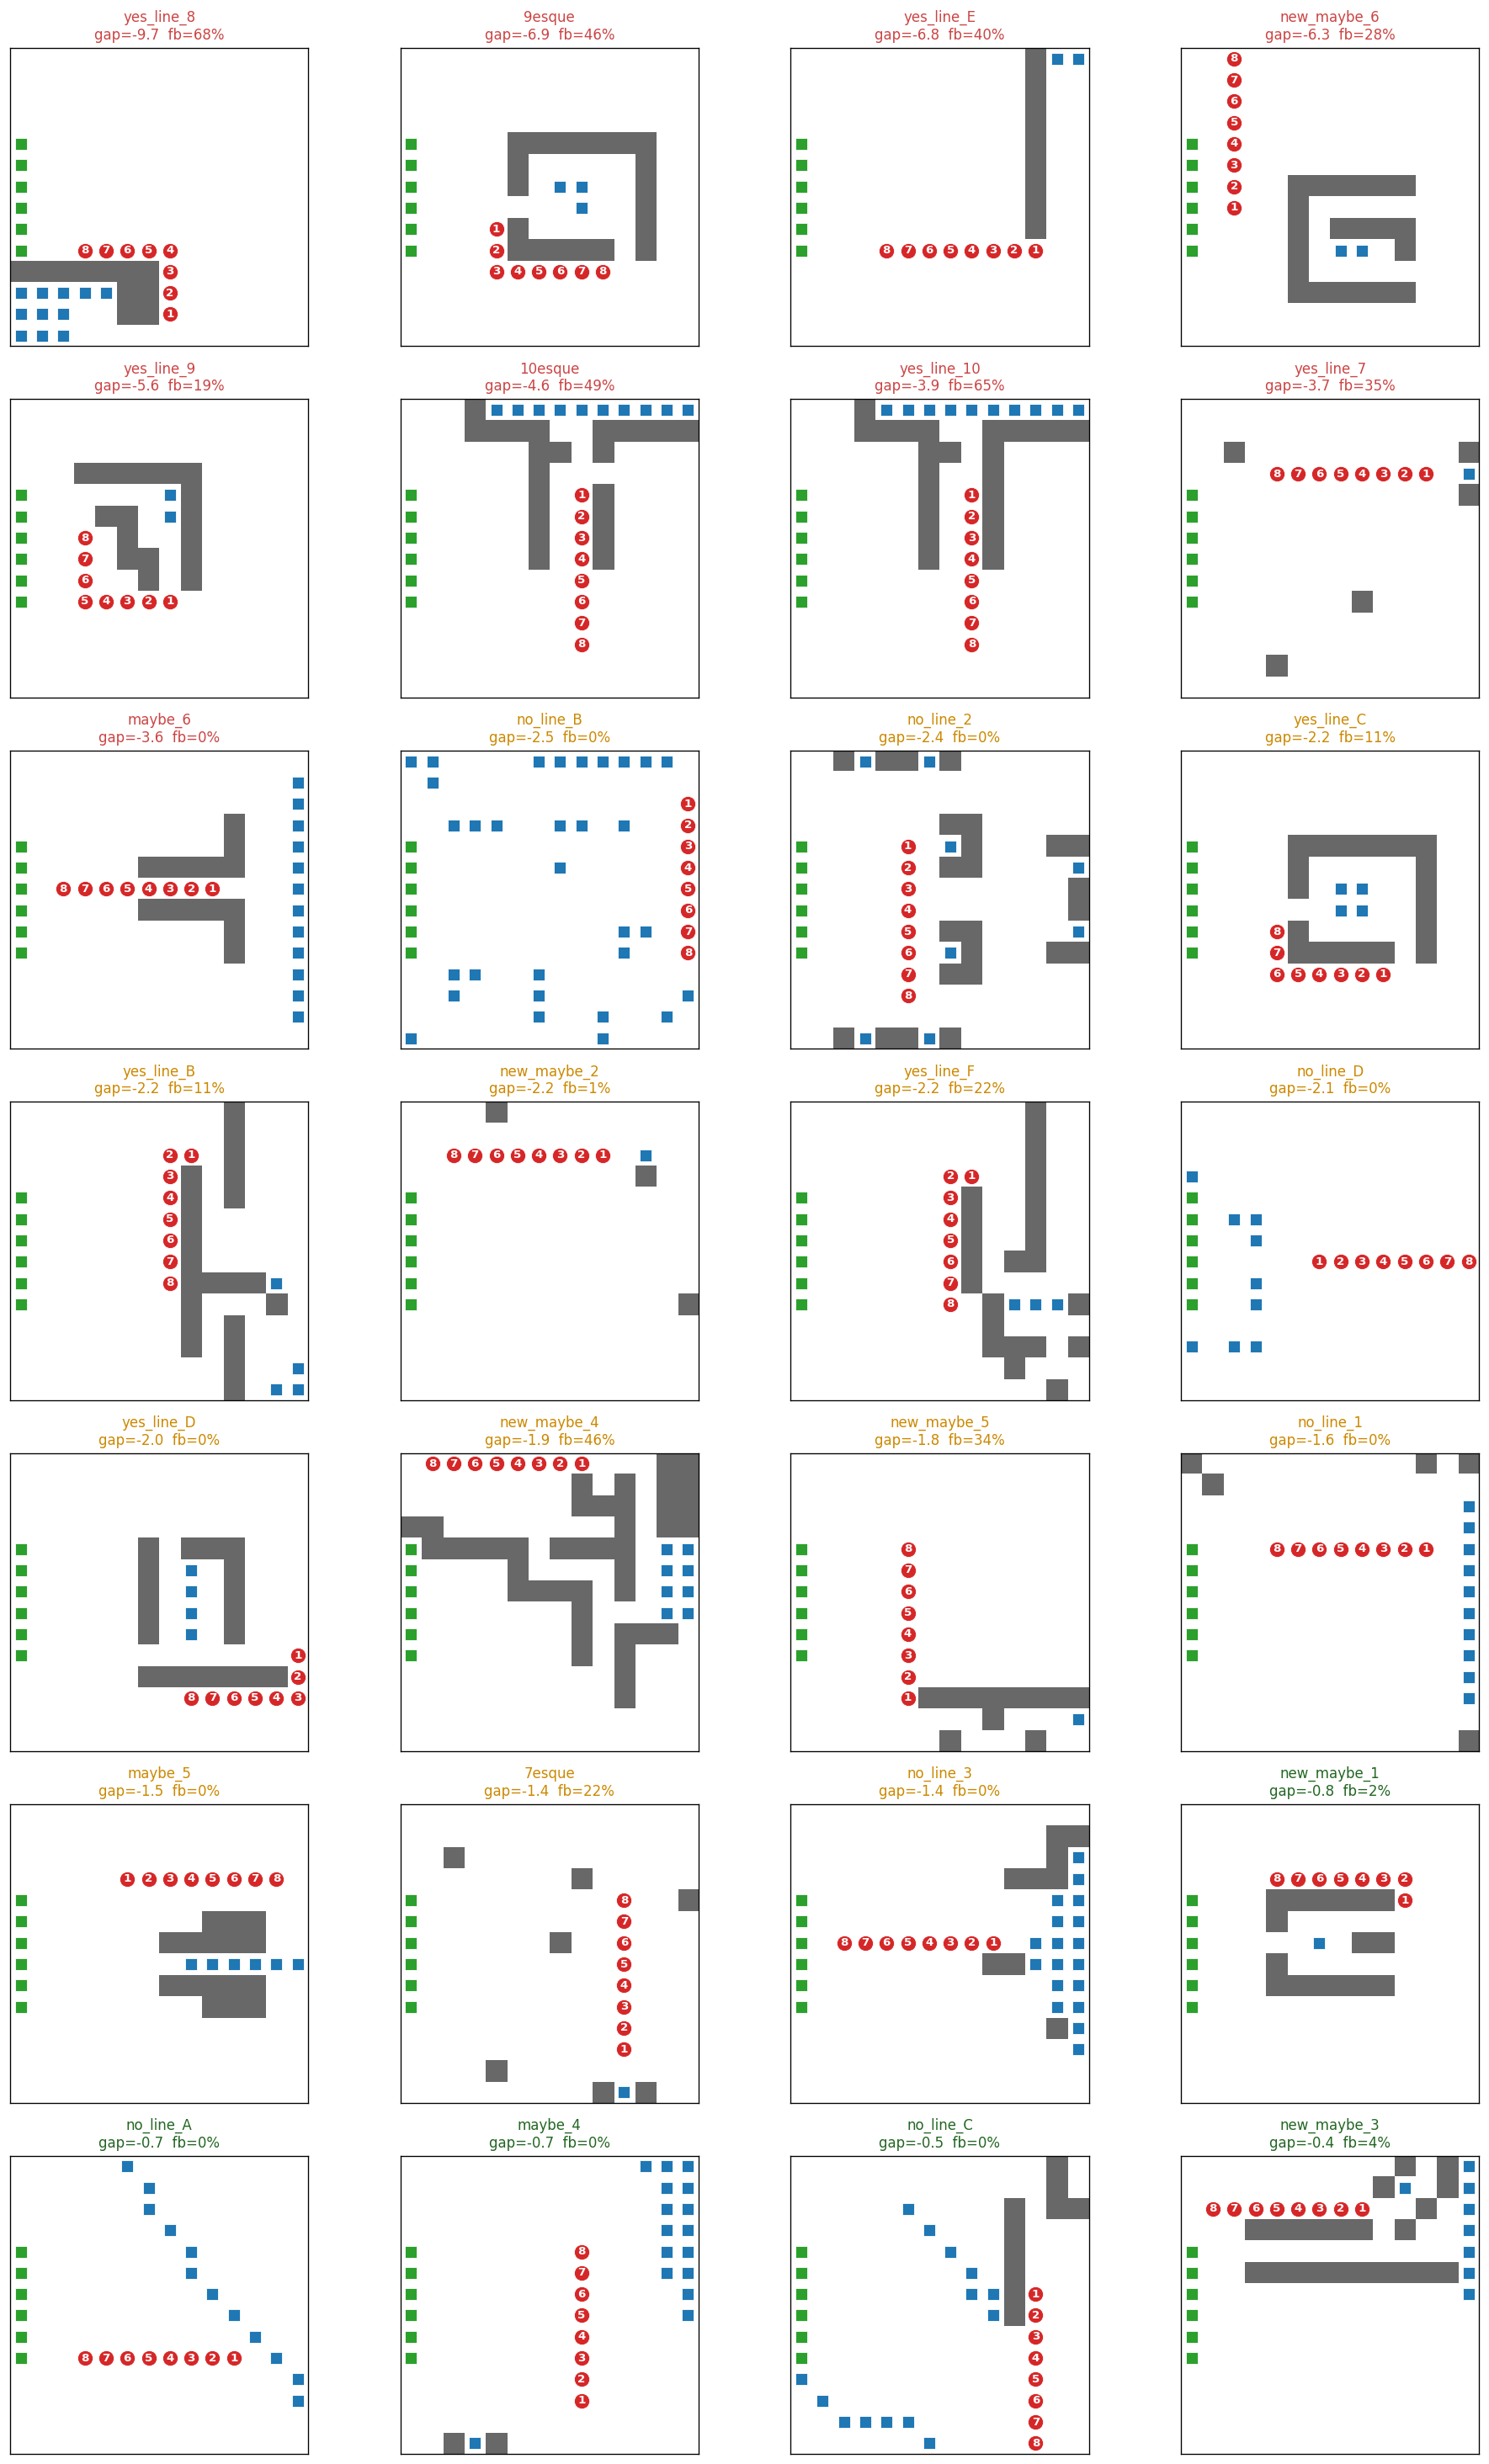

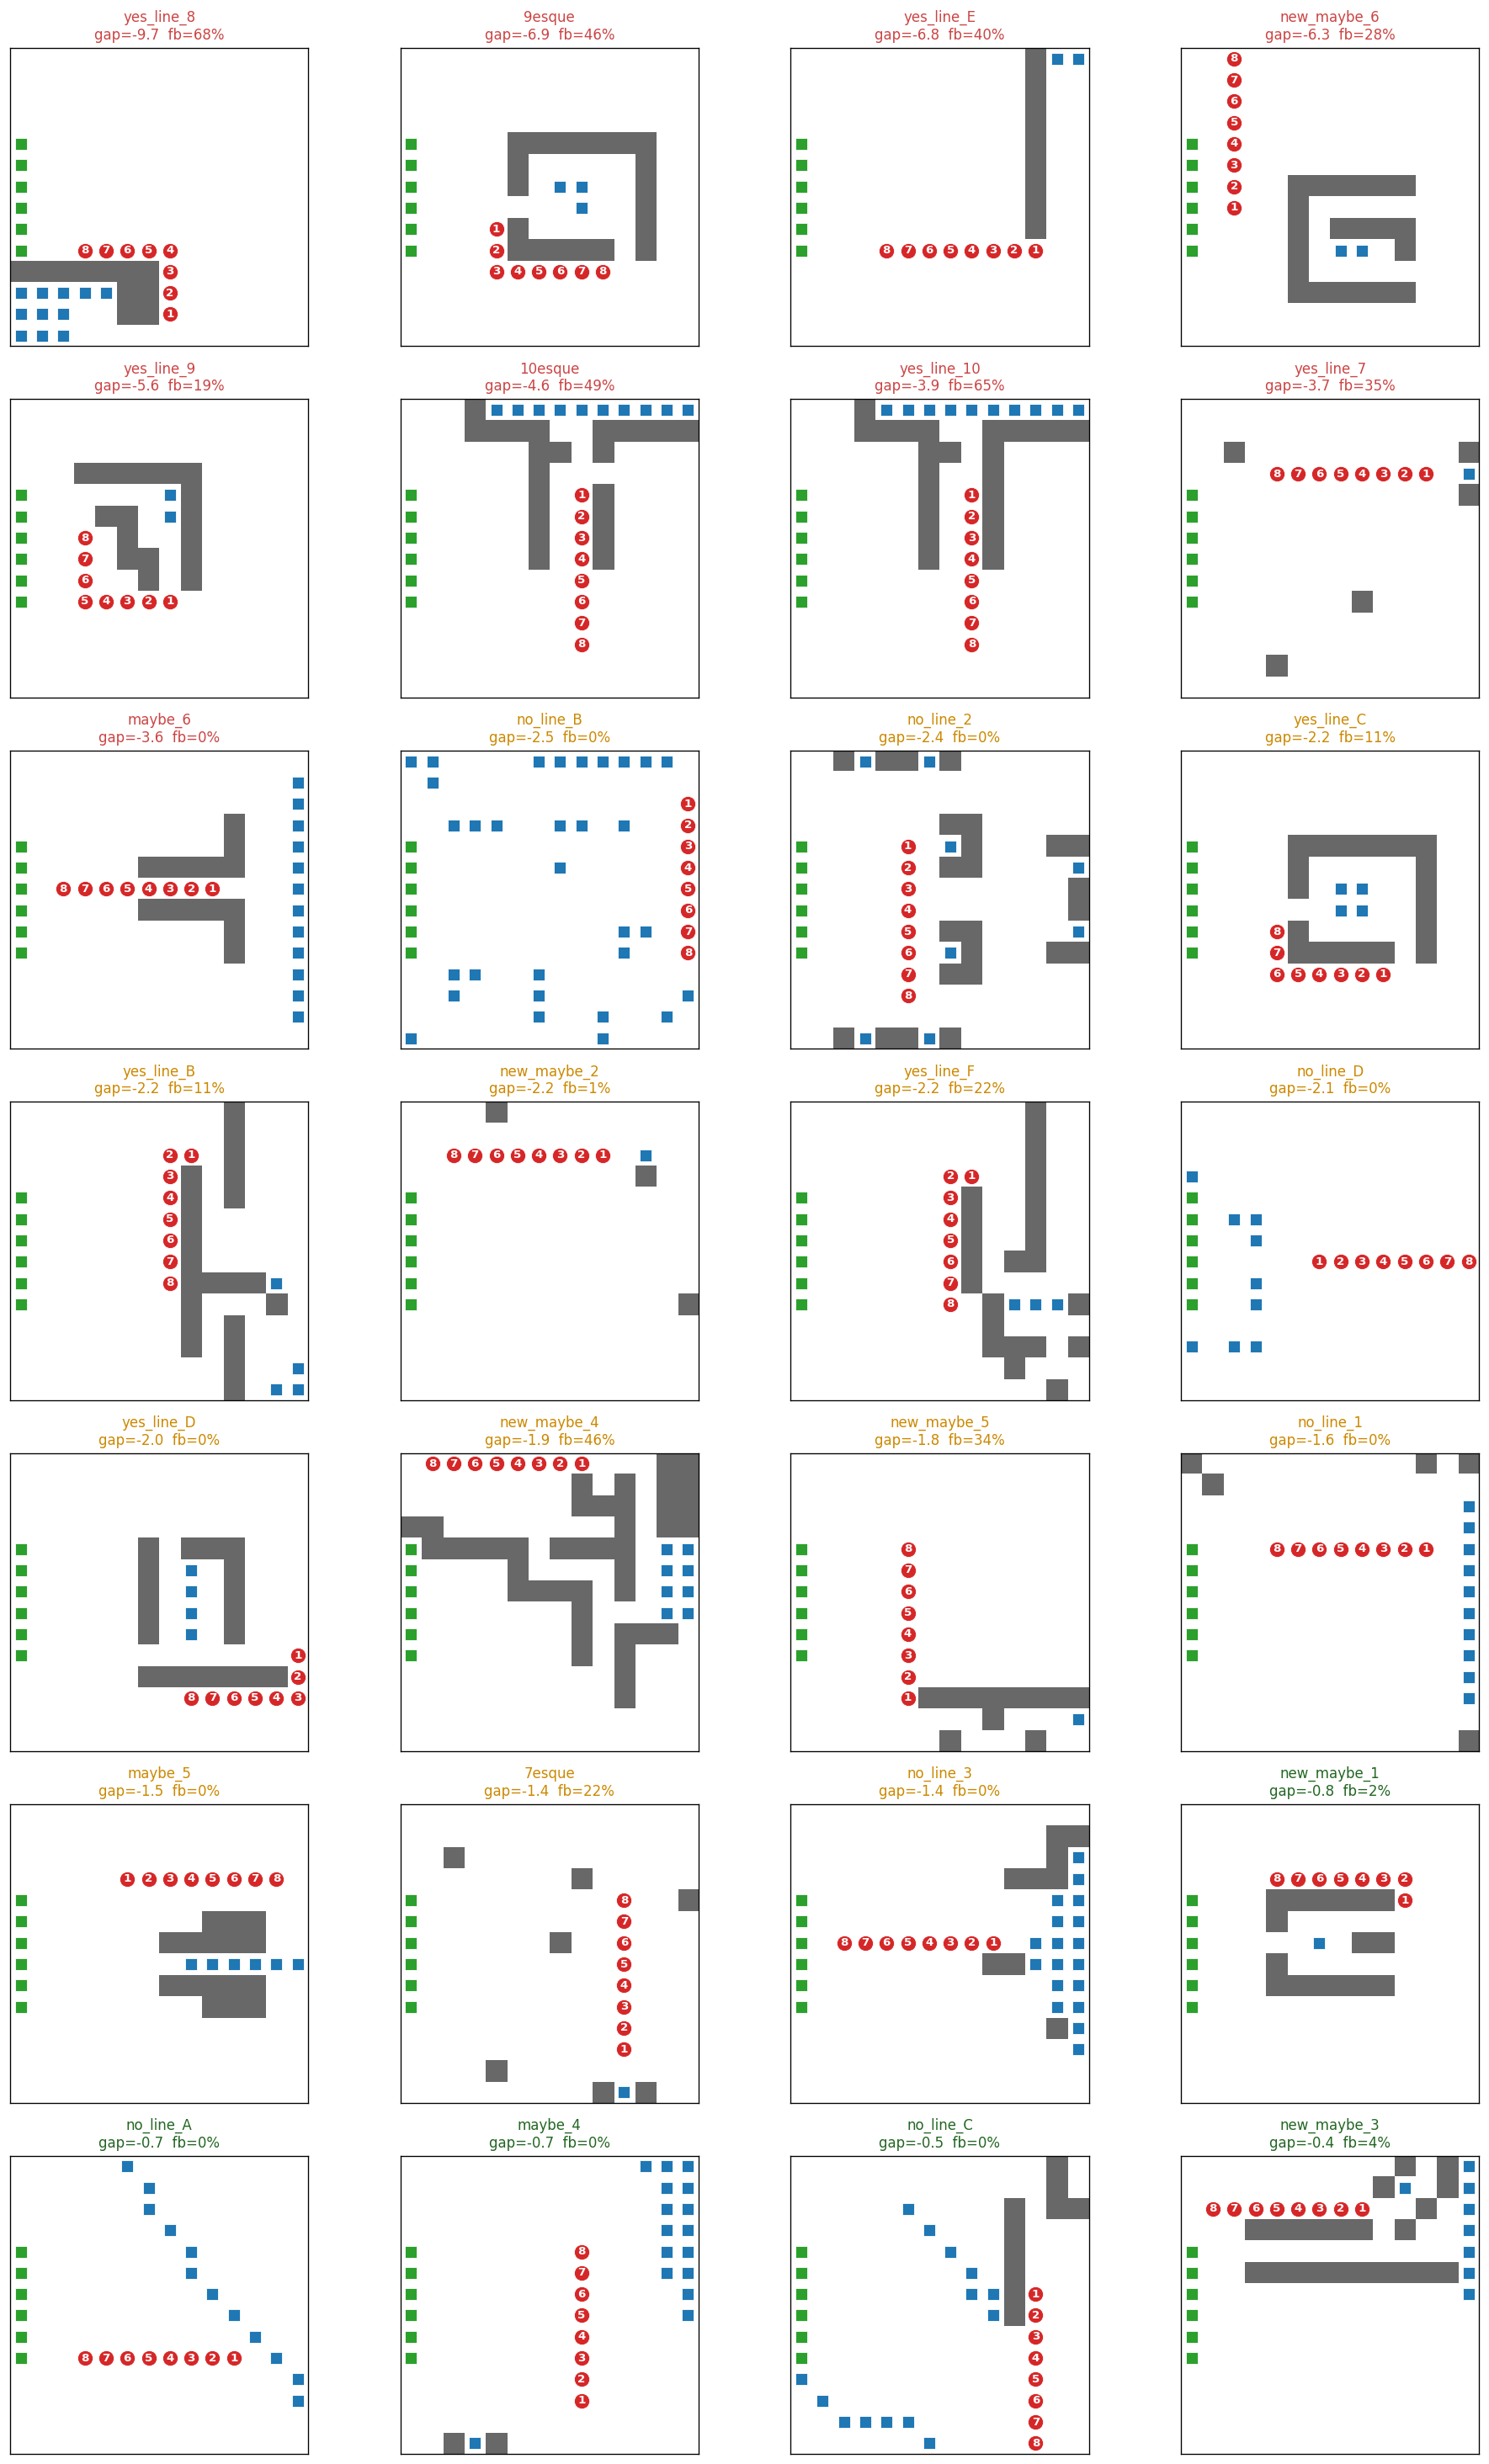

In [66]:
from map_gallery import render_map_gallery
render_map_gallery(full, map_dir=map_dir, save_path='figures/map_gallery.png')

   t= 1 idx=1 k=7 pos=(5, 10) | real_L1: up(agent7)           tag=FALLBACK gap=nan | L1_heur: up(agent7)          
   t= 1 idx=2 k=2 pos=(8, 12) | real_L1: right(agent2)        tag=FALLBACK gap=nan | L1_heur: right(agent2)       
   t= 1 idx=3 k=5 pos=(7, 10) | real_L1: up(agent5)           tag=FALLBACK gap=nan | L1_heur: up(agent5)          
   t= 1 idx=4 k=6 pos=(6, 10) | real_L1: up(agent6)           tag=FALLBACK gap=nan | L1_heur: up(agent6)          
   t= 1 idx=5 k=3 pos=(8, 11) | real_L1: right(agent3)        tag=FALLBACK gap=nan | L1_heur: right(agent3)       
   t= 1 idx=6 k=8 pos=(4, 10) | real_L1: up(agent8)           tag=FALLBACK gap=nan | L1_heur: up(agent8)          
   t= 1 idx=7 k=1 pos=(8, 13) | real_L1: down(agent1)         tag=OK       gap=1.000 | L1_heur: down(agent1)        
>> t= 1 idx=8 k=4 pos=(8, 10) | real_L1: down(agent4)         tag=FALLBACK gap=nan | L1_heur: right(agent4)       
   t= 2 idx=1 k=7 pos=(5, 9) | real_L1: wait(agent7)         tag=FALLBACK gap=

<Axes: title={'center': 'yes_line_8: first divergence'}>

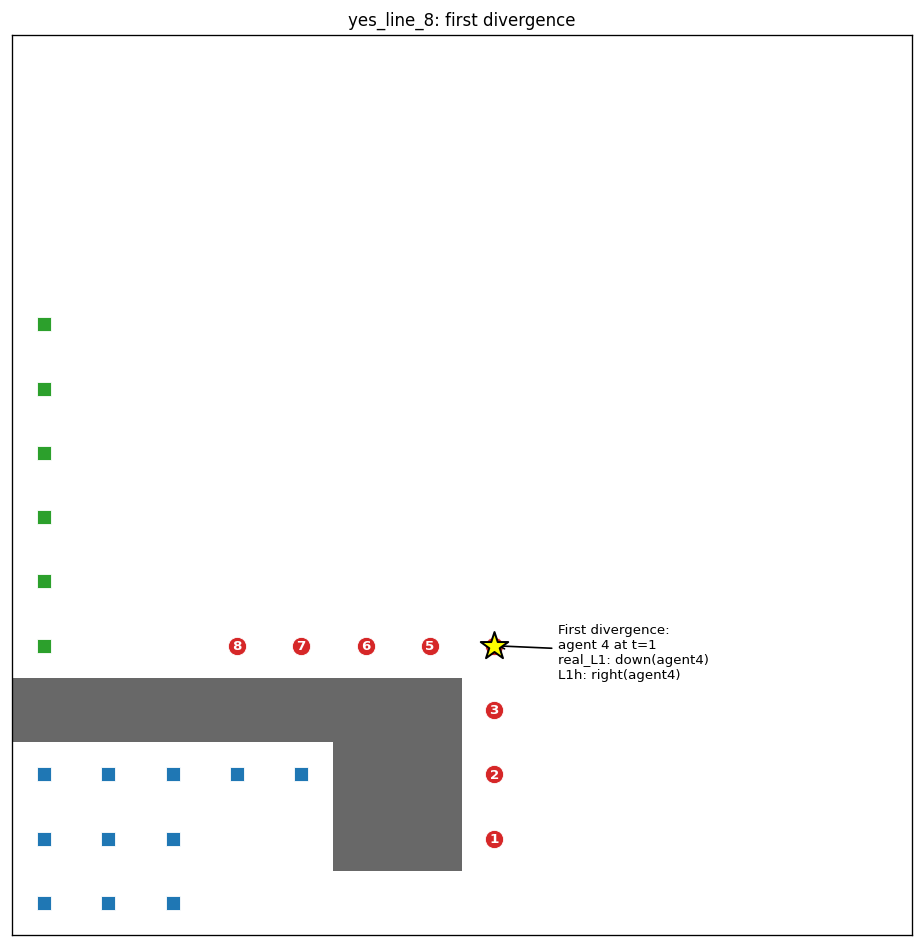

In [67]:
from single_map_deepdive import (
    compare_first_n_decisions, find_first_divergence_with_candidates,
    visualize_map_with_divergence,
)
from map_analysis import load_map

# Find first divergence + show candidates
real_log = '../data/simulations/real_L1_traj_2026-05-05_120942/raw/trajectories/trajectory_yes_line_8_run1.log'
heur_log = '../data/simulations/L1_heuristic_traj_2026-05-05_104641/raw/trajectories/trajectory_yes_line_8_run1.log'

print(compare_first_n_decisions(real_log, heur_log, n=20))

div = find_first_divergence_with_candidates(real_log, heur_log)
print("\nFirst divergence details:")
print(div)

# Visualize on the map
m = load_map(f'{map_dir}/yes_line_8')
visualize_map_with_divergence(m, div, save_path='figures/divergence_yes_line_8.png',
                                title='yes_line_8: first divergence')

In [68]:
# For a map where they agree
real_log_nodiv = '...trajectory_no_line_A_run1.log'
heur_log_nodiv = '...trajectory_no_line_A_run1.log'
print(compare_first_n_decisions(real_log_nodiv, heur_log_nodiv, n=20)

SyntaxError: unexpected EOF while parsing (3877821411.py, line 4)

In [ ]:
# May 13 step 2, vsualization

In [73]:
from trajectory_visualizer import build_visualization
from trajectory_snapshots import snapshots
import os

def visualize_map(map_name,
                  real_run_dir='../data/simulations/real_L1_traj_2026-05-05_120942',
                  heur_run_dir='../data/simulations/L1_heuristic_traj_2026-05-05_104641',
                  pddl_dir='../src/maps',
                  out_dir='figures',
                  run=1,
                  snapshot_timesteps=(0, 3, 6, 10, 15, 20)):
    """Build HTML viewer + static snapshots for one map."""
    real_log = f'{real_run_dir}/raw/trajectories/trajectory_{map_name}_run{run}.log'
    heur_log = f'{heur_run_dir}/raw/trajectories/trajectory_{map_name}_run{run}.log'
    pddl     = f'{pddl_dir}/{map_name}'

    os.makedirs(out_dir, exist_ok=True)

    build_visualization(
        map_path=pddl,
        log_real=real_log,
        log_heur=heur_log,
        output=f'{out_dir}/{map_name}_compare.html',
        labels=('Real L1', 'L1 heuristic'),
    )

    snapshots(
        map_path=pddl,
        log_real=real_log,
        log_heur=heur_log,
        output=f'{out_dir}/{map_name}_snapshots.png',
        timesteps=list(snapshot_timesteps),
    )



In [78]:
MAP_FILES = [
    "no_line_1", "no_line_2", "no_line_3",
    "yes_line_7", "yes_line_8", "yes_line_9", "yes_line_10",
    "7esque", "9esque", "10esque",
    "maybe_4", "maybe_5", "maybe_6",
    "new_maybe_1", "new_maybe_2", "new_maybe_3",
    "new_maybe_4", "new_maybe_5", "new_maybe_6",
    "no_line_A", "no_line_B", "no_line_C", "no_line_D",
    "yes_line_B", "yes_line_C", "yes_line_D", "yes_line_E", "yes_line_F",
]
for m in MAP_FILES:
    visualize_map(m)

Saved figures/no_line_1_compare.html
Open in browser. 59 timesteps loaded.
Saved figures/no_line_1_snapshots.png
Saved figures/no_line_2_compare.html
Open in browser. 32 timesteps loaded.
Saved figures/no_line_2_snapshots.png
Saved figures/no_line_3_compare.html
Open in browser. 1001 timesteps loaded.
Saved figures/no_line_3_snapshots.png
Saved figures/yes_line_7_compare.html
Open in browser. 147 timesteps loaded.
Saved figures/yes_line_7_snapshots.png
Saved figures/yes_line_8_compare.html
Open in browser. 242 timesteps loaded.
Saved figures/yes_line_8_snapshots.png
Saved figures/yes_line_9_compare.html
Open in browser. 122 timesteps loaded.
Saved figures/yes_line_9_snapshots.png
Saved figures/yes_line_10_compare.html
Open in browser. 251 timesteps loaded.
Saved figures/yes_line_10_snapshots.png
Saved figures/7esque_compare.html
Open in browser. 108 timesteps loaded.
Saved figures/7esque_snapshots.png
Saved figures/9esque_compare.html
Open in browser. 139 timesteps loaded.
Saved figure

In [84]:
traj_dirs = {
    'real L1': '../data/simulations/real_L1_traj_2026-05-05_120942',
    'L1 heuristic': '../data/simulations/L1_heuristic_traj_2026-05-05_104641',
}

agent_cols = [f'agent_{k}' for k in range(1, 9)]



for map_name in ['maybe_6', 'no_line_1', 'yes_line_8',  '9esque', 'no_line_A']:
    print(f"\n{'='*60}")
    print(f"MAP: {map_name}")
    print('='*60)
    for tag, d in traj_dirs.items():
        df = pd.read_csv(f"{d}/raw/{map_name}.csv")
        print(f"\n  {tag}:")
        print(df[['run', 'order'] + agent_cols].to_string(index=False))


MAP: maybe_6

  real L1:
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 3, 1, 5, 2, 4, 8, 6]       24       34       32       40       -1       50       -1       -1

  L1 heuristic:
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 3, 1, 5, 2, 4, 8, 6]       28       23       30       34       27       34       35       54

MAP: no_line_1

  real L1:
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 4, 2, 3, 1, 8, 5, 6]       21       25       27       40       29       58       26       33

  L1 heuristic:
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 4, 2, 3, 1, 8, 5, 6]       16       20       20       22       26       34       27       29

MAP: yes_line_8

  real L1:
 run                    order  agent_1  agent_2  agent_3  agent_4  

In [81]:
import pandas as pd

map_name = 'no_line_1'

for tag in ['real L1', 'L1 heuristic']:
    label = RUNS[tag]
    df = pd.read_csv(f"../data/simulations/{label}/raw/{map_name}.csv")
    agent_cols = [f'agent_{k}' for k in range(1, 9)]
    print(f"\n=== {tag} on {map_name} ===")
    print(df[['run', 'order'] + agent_cols].to_string(index=False))


=== real L1 on no_line_1 ===
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 4, 2, 3, 1, 8, 5, 6]       21       25       27       40       29       58       26       33
   2 [6, 5, 2, 8, 3, 4, 7, 1]       25       26       22       33       25       39       77       28
   3 [6, 7, 8, 1, 2, 5, 4, 3]       22       32       27       24       32       26       60       27
   4 [3, 6, 7, 1, 2, 5, 8, 4]       16       19       24       53       23       42       26       78
   5 [7, 2, 1, 8, 3, 4, 5, 6]       -1       -1       -1       -1       -1       -1       -1       -1

=== L1 heuristic on no_line_1 ===
 run                    order  agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
   1 [7, 4, 2, 3, 1, 8, 5, 6]       16       20       20       22       26       34       27       29
   2 [6, 5, 2, 8, 3, 4, 7, 1]       17       19       18       23       25       28       28       32
   3 [6, 7, 8, 1,

In [85]:
from importlib import reload
import trajectory_visualizer; reload(trajectory_visualizer)
import trajectory_snapshots; reload(trajectory_snapshots)
from trajectory_visualizer import build_visualization
from trajectory_snapshots import snapshots
import pandas as pd
import os
import ast

def visualize_map(map_name,
                  real_run_dir='../data/simulations/real_L1_traj_2026-05-05_120942',
                  heur_run_dir='../data/simulations/L1_heuristic_traj_2026-05-05_104641',
                  pddl_dir='../src/maps',
                  out_dir='figures',
                  run=1,
                  snapshot_timesteps=(0, 3, 6, 10, 15, 20)):
    real_log = f'{real_run_dir}/raw/trajectories/trajectory_{map_name}_run{run}.log'
    heur_log = f'{heur_run_dir}/raw/trajectories/trajectory_{map_name}_run{run}.log'
    pddl     = f'{pddl_dir}/{map_name}.pddl'

    # Pull the play order from the CSV
    csv = pd.read_csv(f'{real_run_dir}/raw/{map_name}.csv')
    order_str = csv[csv['run'] == run]['order'].iloc[0]
    # order is a string like "[7, 2, 5, 6, 3, 8, 1, 4]"; safely parse
    order = ast.literal_eval(order_str) if isinstance(order_str, str) else list(order_str)

    os.makedirs(out_dir, exist_ok=True)

    build_visualization(
        map_path=pddl, log_real=real_log, log_heur=heur_log,
        output=f'{out_dir}/{map_name}_compare_new.html',
        labels=('Real L1', 'L1 heuristic'),
        order=order,
    )
    snapshots(
        map_path=pddl, log_real=real_log, log_heur=heur_log,
        output=f'{out_dir}/{map_name}_snapshots_new.png',
        timesteps=list(snapshot_timesteps),
        order=order,
    )

visualize_map('maybe_6')

Saved figures/maybe_6_compare_new.html
Open in browser. 1001 timesteps loaded.
Saved figures/maybe_6_snapshots_new.png


In [86]:
MAP_FILES = [
    "no_line_1", "no_line_2", "no_line_3",
    "yes_line_7", "yes_line_8", "yes_line_9", "yes_line_10",
    "7esque", "9esque", "10esque",
    "maybe_4", "maybe_5", "maybe_6",
    "new_maybe_1", "new_maybe_2", "new_maybe_3",
    "new_maybe_4", "new_maybe_5", "new_maybe_6",
    "no_line_A", "no_line_B", "no_line_C", "no_line_D",
    "yes_line_B", "yes_line_C", "yes_line_D", "yes_line_E", "yes_line_F",
]
for m in MAP_FILES:
    visualize_map(m)

Saved figures/no_line_1_compare_new.html
Open in browser. 59 timesteps loaded.
Saved figures/no_line_1_snapshots_new.png
Saved figures/no_line_2_compare_new.html
Open in browser. 32 timesteps loaded.
Saved figures/no_line_2_snapshots_new.png
Saved figures/no_line_3_compare_new.html
Open in browser. 1001 timesteps loaded.
Saved figures/no_line_3_snapshots_new.png
Saved figures/yes_line_7_compare_new.html
Open in browser. 147 timesteps loaded.
Saved figures/yes_line_7_snapshots_new.png
Saved figures/yes_line_8_compare_new.html
Open in browser. 242 timesteps loaded.
Saved figures/yes_line_8_snapshots_new.png
Saved figures/yes_line_9_compare_new.html
Open in browser. 122 timesteps loaded.
Saved figures/yes_line_9_snapshots_new.png
Saved figures/yes_line_10_compare_new.html
Open in browser. 251 timesteps loaded.
Saved figures/yes_line_10_snapshots_new.png
Saved figures/7esque_compare_new.html
Open in browser. 108 timesteps loaded.
Saved figures/7esque_snapshots_new.png
Saved figures/9esque_

In [ ]:
# May 6 or before analysis

In [56]:
from trajectory_analysis import (
    parse_run_dir, compare_models, aggregate_per_map, overall_summary,
)

# Adjust paths if local copies are elsewhere
real_dir = '../data/simulations/real_L1_traj_2026-05-05_120942/raw/trajectories'
heur_dir = '../data/simulations/L1_heuristic_traj_2026-05-05_104641/raw/trajectories'
l0_dir   = '../data/simulations/L0_traj_2026-05-06_024941/raw/trajectories'

print("Parsing trajectories...")
dec_real = parse_run_dir(real_dir)
dec_heur = parse_run_dir(heur_dir)
dec_l0   = parse_run_dir(l0_dir)

# Real_L1 vs L1 heuristic
print("\n--- real_L1 vs L1 heuristic ---")
diff_real = compare_models(dec_real, dec_heur, tag_a='real_L1', tag_b='L1_heur')
overall_summary(diff_real, tag_a='real_L1')
print("\nPer-map (top 10 by disagreement):")
print(aggregate_per_map(diff_real, tag_a='real_L1').head(10).round(1).to_string(index=False))

# L0 vs L1 heuristic — different question: how often does adding ToM change choices?
print("\n\n--- L0 vs L1 heuristic ---")
diff_l0 = compare_models(dec_l0, dec_heur, tag_a='L0', tag_b='L1_heur')
# L0 has no gap (HEUR tag), but agreement still meaningful
n_total = len(diff_l0)
n_disagree = (~diff_l0['agreed']).sum()
print(f"Overall: {n_disagree}/{n_total} disagreements ({100*n_disagree/n_total:.1f}%)")

Parsing trajectories...
  parsed 28 files, 47719 decisions, 28 maps from trajectories
  parsed 28 files, 16608 decisions, 28 maps from trajectories
  parsed 28 files, 16608 decisions, 28 maps from trajectories

--- real_L1 vs L1 heuristic ---
Overall (15902 decisions):
  disagreement:         11771 (74.0%)
  close-call disagree:   4972 (42.2% of disagreements)
  fallback:              4336 (27.3%)

Per-map (top 10 by disagreement):
        map  n_decisions  pct_disagree  pct_close_of_disagree  pct_fallback  mean_gap_disagree
yes_line_10          972          79.7                   14.2          65.2                0.7
    10esque          814          78.4                   29.5          49.1                0.7
new_maybe_5         2710          78.3                   53.6          33.7                0.3
 yes_line_9          629          78.2                   50.6          19.4                0.6
 yes_line_8          810          78.1                   12.0          68.4              

In [6]:
# How many decisions in each, and what's the structure?
print(f"L0 decisions: {len(dec_l0)}")
print(f"L1h decisions: {len(dec_heur)}")
print()
print("L0 sample:")
print(dec_l0.head(3))
print("\nL1h sample:")
print(dec_heur.head(3))

# Check the merge keys
m = dec_l0.merge(dec_heur, on=['map', 'run', 't', 'idx', 'k'], how='inner', suffixes=('_l0', '_h'))
print(f"\nMerged: {len(m)} rows (should match overall total)")
print(m[['map', 't', 'idx', 'k', 'chose_l0', 'chose_h']].head(10))

L0 decisions: 16608
L1h decisions: 16608

L0 sample:
       map  run  t  idx  k     pos         chose   tag  best  gap
0  10esque    1  1    1  8  (9,12)  left(agent8)  HEUR   NaN  NaN
1  10esque    1  1    2  6  (9,10)  left(agent6)  HEUR   NaN  NaN
2  10esque    1  1    3  4   (9,8)  left(agent4)  HEUR   NaN  NaN

L1h sample:
       map  run  t  idx  k     pos         chose   tag  best  gap
0  10esque    1  1    1  8  (9,12)  left(agent8)  HEUR   NaN  NaN
1  10esque    1  1    2  6  (9,10)  left(agent6)  HEUR   NaN  NaN
2  10esque    1  1    3  4   (9,8)  left(agent4)  HEUR   NaN  NaN

Merged: 16608 rows (should match overall total)
       map  t  idx  k      chose_l0       chose_h
0  10esque  1    1  8  left(agent8)  left(agent8)
1  10esque  1    2  6  left(agent6)  left(agent6)
2  10esque  1    3  4  left(agent4)  left(agent4)
3  10esque  1    4  2  left(agent2)  left(agent2)
4  10esque  1    5  1    up(agent1)    up(agent1)
5  10esque  1    6  5    up(agent5)    up(agent5)
6  10es

In [7]:
nofb = diff_real[diff_real['tag_real_L1'] == 'OK']
print(f"Non-fallback decisions: {len(nofb)}")
print(f"  agreed: {nofb['agreed'].sum()} ({100*nofb['agreed'].mean():.1f}%)")
print(f"  close-call disagree: {((~nofb['agreed']) & (nofb['gap_real_L1'] < 1.0)).sum()}")

Non-fallback decisions: 11525
  agreed: 3172 (27.5%)
  close-call disagree: 4972


In [8]:
m = dec_l0.merge(dec_heur, on=['map','run','t','idx','k'], 
                  how='inner', suffixes=('_l0','_h'))
m['agreed'] = m['chose_l0'] == m['chose_h']

print(f"Overall: {len(m)} merged decisions, {m['agreed'].sum()} agree ({100*m['agreed'].mean():.1f}%)")

# By map
print("\nBy map:")
by_map = m.groupby('map').agg(
    n=('agreed', 'count'),
    n_disagree=('agreed', lambda x: (~x).sum()),
    pct_disagree=('agreed', lambda x: 100*(1-x.mean())),
).sort_values('pct_disagree', ascending=False)
print(by_map.head(15).round(1))

Overall: 16608 merged decisions, 16608 agree (100.0%)

By map:
               n  n_disagree  pct_disagree
map                                       
10esque      832           0           0.0
7esque       504           0           0.0
yes_line_E   792           0           0.0
yes_line_D   400           0           0.0
yes_line_C   560           0           0.0
yes_line_B   944           0           0.0
yes_line_9   648           0           0.0
yes_line_8   824           0           0.0
yes_line_7   496           0           0.0
yes_line_10  984           0           0.0
no_line_D    312           0           0.0
no_line_C    208           0           0.0
no_line_B    208           0           0.0
no_line_A    208           0           0.0
no_line_3    280           0           0.0


In [10]:
print(RUNS['real L1'])
print(RUNS['L1 heuristic'])

NameError: name 'RUNS' is not defined

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from new_comparison_utils import (
    load_experiments, load_simulations, load_outcome_metrics,
    build_all_design_matrices,
    evaluate_fits, evaluate_fits_multi,
    correlation_matrix, full_correlation_matrix,
    split_half_all,
    plot_grouped_bars, plot_eval_multi, plot_scatter, plot_simple_regression
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [38]:
# ── Define simulation runs ──
# tag → directory name under data/simulations/

RUNS = {
    # Baselines
    #'joe':          'joe_1_02-06',
    #'random_full':  'full_random_02-06',
    
    # v1 (random order redrawn every timestep)
    #'depth0':       'depth0_03-16',
    #'depth1':       'depth1_03-16',
    #'depth2':       'depth2_03-16',
    
    # v2 (order drawn once)
    #'depth0_v2':    'v2_d0_03-21',
    #'depth1_v2':    'v2_d1_03-21',
    #'depth2_v2':    'v2_d2_03-21',

    # v3 (order drawn once, everyone sees one step behind rather than at beginning of timestep)
    #'depth0_v3':    'v3_d0_03-24',
    #'depth1_v3':    'v3_d1_03-23',
    #'depth2_v3_1run':    'v3_d2_1run',

    # v4 (fix observation bug in v3 and v2, where agents knew where others we going)
    #'depth0_v4':    'v4_d0',

    # Returning to basics: order drawn once, no depth 
    #'depth0_v1':        'test2_order_drawn_once_2026-04-02_104848', ## FAiled: information leakage
    #'depth0_v2':        'test3_order_once_but_snapshot_timestep_2026-04-02_123334', # Attempt at blind_l0 but with order drawn once
    #'depth0_v3':        'test4_snapshot_2026-04-02_132345', # Attempt at real depth0 --- info leaked
    #'depth0_v3_bis':    'test5_snapshot_nomemoization_2026-04-02_143134', # Real depth0 attempt2 --- test without memoization

    # Laisse beton le snapshot - all plan from start of timestep
    #'depth0_v4': 'depth0_2026-04-02_155550',
    #'depth1_v4': 'depth1_2026-04-02_162801',
    #'depth2_v4': 'depth2_2026-04-02_184604', # failed: agents got stucks (leading to positive universalization scores) 
    #'depth2_v5': 'depth2_fix_2026-04-03_090825',
    #'depth2_v6': 'depth2_more_complex_2026-04-07_122251', # failed: agents got stuck (version where A* done for all routes)

     # 
    #'L0 (1 run only)': 'depth0_2026-04-02_155550',
    'L0': 'depth0_cluster',
    #'L1 heuristic (1 run only)': 'depth1_2026-04-02_162801', # CHECKED: identical (to remove once 3 new maps on cluster)
    'L1 heuristic': 'depth1_main5_cluster',
    #'depth2_v1': 'depth2_fix_2026-04-03_090825', # PROBLEM: less knowledge than depth1, just plans assuming others are two steps ahead
    ##### why is depth2_v1 working so well then? Just lucky?
    #### CHECKED; NOT IDENTICAL BECAUSE SEEDS ARE NOT THE SAME --- bcz I didn't run everything in one go...
    #'real L1 (1 run only)': 'real_l1_2026-04-09_150543', # [depth>=2 stats] fallbacks: 4773 / 48054 decisions (9.93%)
    'real L1': 'depth2_v3_main5_cluster',
    #### FALSE BUG ALERT April 26: agents aren't taking the worse path, Claude be damned
    #'real L1_7': 'realL1_main7_c1', 
    #'real L1_7_2': 'realL1_main7_c2',
    ### Ran wrong script (re-ran old script that didn't coverge for d>1 and didn't have levels)
    #'l0_d0': 'L0_main3_2026-04-11_062738',
    #'l0_d1': 'L1h_main3_2026-04-11_070102',
    #'l0_d2': 'real_L1_main3_2026-04-11_020808',
    #'l0_d3': 'real_L1_d3_2026-04-11_081045',
    'L2 heuristic': 'l2_heuristic_cluster',
    #'real L2 (1 run only)': 'real_L2_2026-04-12_141306',
    'real L2': 'real_L2_merged',
    'L3 heuristic': 'l3_heuristic_cluster',
    # 
    'blind L0':     'blind_L0_random_02-06',
    'blind L1':     'blind_l1_random_02-06',
    'joe': 'joe_1_02-06',
    #'joe_full': 'paper_data',
    #'depth2_v1': 'depth2_v1_cluster',
    #'depth2_v2': 'depth2_withk_2026-04-08_144157',
    #'depth2_v2': 'depth2_v2_cluster',
   # 'cogsci2023': 'paper_data',
    'real_L1_traj': 'real_L1_traj_2026-05-05_120942',
    'L1_heuristic_traj': 'L1_heuristic_traj_2026-05-05_104641',
}

sims = load_simulations(RUNS, recompute=True)

### WATCH OUT FOR RUNS WHERE STUCK, they can contribute to positive univ score / should probably get excluded from summary (when we "build")?

Processed 28 maps for run_label='depth0_cluster' and saved to ../data/simulations/depth0_cluster/processed
Built universalization summary for run_label='depth0_cluster' over 28 maps and saved to summary_universalization_metrics.csv
  Excluded 1/140 stuck runs (0.7%)
  L0                    28 maps, 5 runs  mean U_AW=-3.637  stuck=1/140 (0.7%)
Processed 28 maps for run_label='depth1_main5_cluster' and saved to ../data/simulations/depth1_main5_cluster/processed
Built universalization summary for run_label='depth1_main5_cluster' over 28 maps and saved to summary_universalization_metrics.csv
  L1 heuristic          28 maps, 5 runs  mean U_AW=-1.239  stuck=0/140 (0.0%)
Processed 28 maps for run_label='depth2_v3_main5_cluster' and saved to ../data/simulations/depth2_v3_main5_cluster/processed
Built universalization summary for run_label='depth2_v3_main5_cluster' over 28 maps and saved to summary_universalization_metrics.csv
  Excluded 15/140 stuck runs (10.7%)
  real L1               28 maps

In [39]:
# Compare aggregate metrics from verbose run vs original run
import pandas as pd

for tag, verbose_dir in [
    ('L1 heuristic', 'L1_heuristic_traj_2026-05-05_104641'),
    ('real L1', 'real_L1_traj_2026-05-05_120942'),
]:
    print(f"\n=== {tag} ===")
    for kind, label in [('original', RUNS[tag]), ('verbose', verbose_dir)]:
        df = pd.read_csv(f"../data/simulations/{label}/raw/yes_line_8.csv")
        # Average aggregate_welfare
        valid = df[~df['stuck']] if 'stuck' in df.columns else df
        if 'aggregate_welfare' not in valid.columns:
            # build it
            pass
        mean_aw = valid.iloc[0:1].apply(lambda r: -sum(r[f'agent_{k}'] for k in range(1,9))/8, axis=1).mean()
        print(f"  {kind} ({label}): yes_line_8 run 1 mean_aw ≈ {mean_aw:.2f}")


=== L1 heuristic ===
  original (depth1_main5_cluster): yes_line_8 run 1 mean_aw ≈ -69.38
  verbose (L1_heuristic_traj_2026-05-05_104641): yes_line_8 run 1 mean_aw ≈ -69.38

=== real L1 ===
  original (depth2_v3_main5_cluster): yes_line_8 run 1 mean_aw ≈ -143.50
  verbose (real_L1_traj_2026-05-05_120942): yes_line_8 run 1 mean_aw ≈ -143.50


In [40]:
# What's the fallback rate per-map, and what's the disagreement rate among non-fallback only?
import pandas as pd

per_map = []
for m, sub in diff_real.groupby('map'):
    n_total = len(sub)
    n_fb = (sub['tag_real_L1'] == 'FALLBACK').sum()
    nofb = sub[sub['tag_real_L1'] == 'OK']
    n_nofb_disagree = (~nofb['agreed']).sum()
    per_map.append({
        'map': m,
        'n_total': n_total,
        'pct_fallback': 100*n_fb/n_total,
        'n_nofb': len(nofb),
        'pct_disagree_nofb': 100*n_nofb_disagree/max(len(nofb),1),
    })
pd.DataFrame(per_map).sort_values('pct_fallback', ascending=False).round(1)

,map,n_total,pct_fallback,n_nofb,pct_disagree_nofb
21,yes_line_8,810,68.4,249,77.5
19,yes_line_10,972,65.2,337,78.9
0,10esque,814,49.1,413,80.4
9,new_maybe_4,832,46.4,446,74.2
2,9esque,421,45.6,229,76.4
26,yes_line_E,778,39.6,470,78.5
20,yes_line_7,474,34.8,309,72.2
10,new_maybe_5,2710,33.7,1798,78.0
11,new_maybe_6,647,28.4,461,65.3
1,7esque,483,22.4,372,78.0


In [16]:
import pandas as pd
import numpy as np
import os
from glob import glob
from importlib import reload
import trajectory_analysis; reload(trajectory_analysis)
from trajectory_analysis import parse_run_dir, compare_models

# ---------- TRAJECTORY: parse and compare ----------
real_dir = '../data/simulations/real_L1_traj_2026-05-05_120942/raw/trajectories'
heur_dir = '../data/simulations/L1_heuristic_traj_2026-05-05_104641/raw/trajectories'

dec_real = parse_run_dir(real_dir)
dec_heur = parse_run_dir(heur_dir)
diff = compare_models(dec_real, dec_heur, tag_a='real_L1', tag_b='L1_heur')

# ---------- OUTCOMES: load CSVs ----------
real_csv_dir = '../data/simulations/real_L1_traj_2026-05-05_120942/raw'
heur_csv_dir = '../data/simulations/L1_heuristic_traj_2026-05-05_104641/raw'

def load_outcomes(csv_dir):
    rows = []
    for fn in sorted(os.listdir(csv_dir)):
        if not fn.endswith('.csv'): continue
        df = pd.read_csv(f"{csv_dir}/{fn}")
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

real_out = load_outcomes(real_csv_dir)
heur_out = load_outcomes(heur_csv_dir)

# Only valid (non-stuck) runs
real_out['valid'] = (real_out[[f'agent_{k}' for k in range(1,9)]] > 0).all(axis=1)
heur_out['valid'] = (heur_out[[f'agent_{k}' for k in range(1,9)]] > 0).all(axis=1)

# ---------- BUILD COMBINED PER-MAP TABLE ----------
agent_cols = [f'agent_{k}' for k in range(1,9)]

per_map = []
for m in sorted(real_out['map'].unique()):
    real_m = real_out[real_out['map'] == m]
    heur_m = heur_out[heur_out['map'] == m]
    
    # Outcome metrics (for run 1, since trajectory is RUNS=1)
    if len(real_m) == 0 or len(heur_m) == 0:
        continue
    rr = real_m.iloc[0]
    hh = heur_m.iloc[0]
    
    real_stuck = any(rr[c] <= 0 for c in agent_cols)
    heur_stuck = any(hh[c] <= 0 for c in agent_cols)
    
    real_fills = [rr[c] for c in agent_cols if rr[c] > 0]
    heur_fills = [hh[c] for c in agent_cols if hh[c] > 0]
    
    real_uaw = -np.mean(real_fills) if real_fills else np.nan
    heur_uaw = -np.mean(heur_fills) if heur_fills else np.nan
    
    real_mean_t = np.mean(real_fills) if real_fills else np.nan
    heur_mean_t = np.mean(heur_fills) if heur_fills else np.nan
    
    # Per-agent gap (positive = real_L1 is slower for this agent)
    per_agent_gaps = []
    for c in agent_cols:
        r, h = rr[c], hh[c]
        if r > 0 and h > 0:
            per_agent_gaps.append(r - h)
    max_agent_gap = max(per_agent_gaps) if per_agent_gaps else np.nan
    
    # Trajectory metrics for this map
    diff_m = diff[diff['map'] == m]
    n_dec = len(diff_m)
    if n_dec == 0:
        traj_row = {'pct_disagree': np.nan, 'pct_fallback': np.nan,
                    'pct_disagree_nofb': np.nan, 'pct_close_of_disagree': np.nan}
    else:
        n_disagree = (~diff_m['agreed']).sum()
        n_fb = (diff_m['tag_real_L1'] == 'FALLBACK').sum()
        nofb = diff_m[diff_m['tag_real_L1'] == 'OK']
        n_nofb_disagree = (~nofb['agreed']).sum()
        n_close = ((~diff_m['agreed']) & (diff_m['gap_real_L1'] < 1.0)).sum()
        traj_row = {
            'pct_disagree': 100*n_disagree/n_dec,
            'pct_fallback': 100*n_fb/n_dec,
            'pct_disagree_nofb': 100*n_nofb_disagree/max(len(nofb),1),
            'pct_close_of_disagree': 100*n_close/max(n_disagree,1),
        }
    
    per_map.append({
        'map': m,
        'real_stuck': real_stuck,
        'heur_stuck': heur_stuck,
        'real_uaw': real_uaw,
        'heur_uaw': heur_uaw,
        'uaw_gap': (real_uaw - heur_uaw) if (real_fills and heur_fills) else np.nan,
        'real_mean_t': real_mean_t,
        'heur_mean_t': heur_mean_t,
        'mean_t_gap': (real_mean_t - heur_mean_t) if (real_fills and heur_fills) else np.nan,
        'max_agent_gap': max_agent_gap,
        **traj_row,
    })

result = pd.DataFrame(per_map)

# Sort by uaw_gap (most-divergent maps first)
result = result.sort_values('uaw_gap', ascending=True)

print(result.round(1).to_string(index=False))

  parsed 28 files, 47719 decisions, 28 maps from trajectories
  parsed 28 files, 16608 decisions, 28 maps from trajectories
        map  real_stuck  heur_stuck  real_uaw  heur_uaw  uaw_gap  real_mean_t  heur_mean_t  mean_t_gap  max_agent_gap  pct_disagree  pct_fallback  pct_disagree_nofb  pct_close_of_disagree
yes_line_10       False       False    -161.1     -81.1    -80.0        161.1         81.1        80.0            133          79.7          65.2               78.9                   14.2
 yes_line_8       False       False    -143.5     -69.4    -74.1        143.5         69.4        74.1            160          78.1          68.4               77.5                   12.0
    10esque       False       False    -114.2     -61.8    -52.5        114.2         61.8        52.5            126          78.4          49.1               80.4                   29.5
     9esque       False       False     -91.0     -39.1    -51.9         91.0         39.1        51.9             87       

In [17]:
diff_t1 = diff[diff['t'] == 1]
print(f"At t=1 only: {len(diff_t1)} decisions")
n_disagree = (~diff_t1['agreed']).sum()
n_fb = (diff_t1['tag_real_L1'] == 'FALLBACK').sum()
print(f"  disagreement: {100*n_disagree/len(diff_t1):.1f}%")
print(f"  fallback: {100*n_fb/len(diff_t1):.1f}%")

nofb = diff_t1[diff_t1['tag_real_L1'] == 'OK']
print(f"  non-fallback disagreement: {100*(~nofb['agreed']).sum()/max(len(nofb),1):.1f}%")

At t=1 only: 224 decisions
  disagreement: 36.2%
  fallback: 23.7%
  non-fallback disagreement: 33.7%


In [18]:
diff_t1 = diff[diff['t'] == 1]
nofb = diff_t1[diff_t1['tag_real_L1'] == 'OK']
disagree_t1 = nofb[~nofb['agreed']]
print(f"  Non-fallback disagreements at t=1: {len(disagree_t1)}")
print(f"  Of those, close calls (gap < 1.0): {(disagree_t1['gap_real_L1'] < 1.0).sum()} ({100*(disagree_t1['gap_real_L1'] < 1.0).sum()/max(len(disagree_t1),1):.1f}%)")
print(f"  Mean gap of disagreements: {disagree_t1['gap_real_L1'].mean():.2f}")
print(f"  Median gap: {disagree_t1['gap_real_L1'].median():.2f}")

  Non-fallback disagreements at t=1: 57
  Of those, close calls (gap < 1.0): 31 (54.4%)
  Mean gap of disagreements: 0.46
  Median gap: 0.00


In [19]:
# Pull SD per map for real_L1, sort high-to-low
high_sd = sims['real L1'].sort_values('univ_aggregate_welfare_sd', ascending=False).head(8)[
    ['map', 'univ_aggregate_welfare', 'univ_aggregate_welfare_sd']
]
print(high_sd.round(2))

            map  univ_aggregate_welfare  univ_aggregate_welfare_sd
2        9esque                   -8.99                       6.11
21   yes_line_8                  -14.58                       3.72
16    no_line_B                   -0.36                       2.92
5       maybe_6                   -2.92                       2.82
11  new_maybe_6                  -10.17                       2.06
19  yes_line_10                   -8.17                       1.59
18    no_line_D                   -1.44                       1.54
13    no_line_2                   -0.05                       1.48


In [20]:
import pandas as pd

# Per-map t=1 disagreement
diff_t1 = diff[diff['t'] == 1]
nofb_t1 = diff_t1[diff_t1['tag_real_L1'] == 'OK']

per_map_t1 = []
for m, sub in diff_t1.groupby('map'):
    nofb = sub[sub['tag_real_L1'] == 'OK']
    per_map_t1.append({
        'map': m,
        'n_t1_decisions': len(sub),
        'pct_fallback_t1': 100 * (sub['tag_real_L1'] == 'FALLBACK').sum() / max(len(sub), 1),
        'n_nofb': len(nofb),
        'pct_disagree_nofb_t1': 100 * (~nofb['agreed']).sum() / max(len(nofb), 1),
    })

t1_table = pd.DataFrame(per_map_t1)

# Sort by something useful — uaw_gap from earlier
result_with_t1 = t1_table.merge(
    result[['map', 'uaw_gap']],
    on='map'
).sort_values('uaw_gap')
print(result_with_t1.round(1).to_string(index=False))

        map  n_t1_decisions  pct_fallback_t1  n_nofb  pct_disagree_nofb_t1  uaw_gap
yes_line_10               8             87.5       1                   0.0    -80.0
 yes_line_8               8             87.5       1                   0.0    -74.1
    10esque               8             87.5       1                 100.0    -52.5
     9esque               8             75.0       2                  50.0    -51.9
 yes_line_E               8              0.0       8                  75.0    -47.2
new_maybe_6               8              0.0       8                  12.5    -32.0
 yes_line_7               8             87.5       1                   0.0    -22.6
new_maybe_4               8              0.0       8                   0.0    -18.1
 yes_line_9               8              0.0       8                  25.0    -15.8
 yes_line_D               8              0.0       7                  57.1    -13.2
     7esque               8             87.5       1                   0.0  

In [21]:
# Disagreement rate by timestep, for hard vs easy maps
hard_maps = ['yes_line_10', 'yes_line_8', '10esque', '9esque', 'yes_line_E', 'new_maybe_6']
easy_maps = ['no_line_A', 'no_line_B', 'no_line_C', 'no_line_D', 'no_line_1', 'no_line_2']

for tag, mlist in [('hard', hard_maps), ('easy', easy_maps)]:
    sub = diff[diff['map'].isin(mlist)]
    print(f"\n{tag} maps:")
    for tval in [1, 2, 3, 5, 10, 20]:
        sub_t = sub[sub['t'] == tval]
        if len(sub_t) == 0: continue
        nofb = sub_t[sub_t['tag_real_L1'] == 'OK']
        fb = (sub_t['tag_real_L1'] == 'FALLBACK').sum()
        print(f"  t={tval:2d}: n={len(sub_t):4d}, fallback={100*fb/len(sub_t):4.0f}%, "
              f"disagree_nofb={100*(~nofb['agreed']).sum()/max(len(nofb),1):4.0f}%")


hard maps:
  t= 1: n=  48, fallback=  56%, disagree_nofb=  43%
  t= 2: n=  48, fallback=  56%, disagree_nofb=  43%
  t= 3: n=  48, fallback=  56%, disagree_nofb=  29%
  t= 5: n=  46, fallback=  57%, disagree_nofb=  45%
  t=10: n=  47, fallback=  53%, disagree_nofb=  73%
  t=20: n=  41, fallback=  46%, disagree_nofb=  77%

easy maps:
  t= 1: n=  48, fallback=   0%, disagree_nofb=  31%
  t= 2: n=  44, fallback=   0%, disagree_nofb=  25%
  t= 3: n=  40, fallback=   2%, disagree_nofb=  28%
  t= 5: n=  34, fallback=   0%, disagree_nofb=  38%
  t=10: n=  34, fallback=   0%, disagree_nofb=  32%
  t=20: n=  39, fallback=   0%, disagree_nofb=  72%


In [22]:
from trajectory_figures import fig_fallback_vs_gap, fig_disagreement_when_evaluating

# `result` is the per_map dataframe you computed earlier (with uaw_gap, pct_fallback, etc.)
fig_fallback_vs_gap(result, save_path='figures/fallback_vs_gap.png')

# `diff` is the output of compare_models()
fig_disagreement_when_evaluating(
    diff, result,
    save_path='figures/disagreement_per_map.png'
)

ModuleNotFoundError: No module named 'trajectory_figures'

In [23]:
"""
Trajectory analysis figures:
1. fig_fallback_vs_gap: scatter of fallback rate vs U_AW gap across maps
2. fig_disagreement_by_map: t=1 disagreement rate per map, with macro-type color

Both designed to fit on a meeting slide and tell the mechanism story.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _macro_type(name):
    name = str(name)
    if 'no_line' in name: return 'no_line'
    if 'yes_line' in name: return 'yes_line'
    return 'maybe/other'


MACRO_COLORS = {
    'no_line': 'tab:blue',
    'yes_line': 'tab:red',
    'maybe/other': 'tab:green',
}


def fig_fallback_vs_gap(per_map_df,
                         fallback_col='pct_fallback',
                         gap_col='uaw_gap',
                         label_threshold_gap=-15,
                         label_threshold_fallback=40,
                         save_path=None):
    """
    Scatter: fallback rate (x) vs U_AW gap (y) per map.

    The story: high fallback ≈ broken forward-sim ≈ underperformance on hard maps.
    Easy maps cluster at origin (low fallback, small gap regardless of sign).

    per_map_df must have columns: 'map', fallback_col, gap_col.
    """
    df = per_map_df.copy()
    df['macro'] = df['map'].apply(_macro_type)

    fig, ax = plt.subplots(figsize=(7, 5.5))

    # Reference line at gap=0
    ax.axhline(0, color='#CCC', linewidth=1, linestyle='--', zorder=0)

    for macro, color in MACRO_COLORS.items():
        sub = df[df['macro'] == macro]
        if len(sub) == 0: continue
        ax.scatter(sub[fallback_col], sub[gap_col],
                   c=color, s=60, alpha=0.75,
                   edgecolor='white', linewidth=0.5,
                   label=macro, zorder=2)

    # Label maps that have either notable fallback OR notable gap
    for _, row in df.iterrows():
        if (row[gap_col] < label_threshold_gap or
            row[fallback_col] > label_threshold_fallback):
            ax.annotate(row['map'], (row[fallback_col], row[gap_col]),
                        fontsize=8, color='#444',
                        xytext=(5, 3), textcoords='offset points')

    ax.set_xlabel('Fallback rate (%)\n(forward-sim returned −∞ for all candidates)',
                  fontsize=10)
    ax.set_ylabel('U_AW gap (real_L1 − L1 heuristic)\n(more negative = real_L1 worse)',
                  fontsize=10)
    ax.set_title("Hard maps: forward-sim breakdown predicts underperformance",
                 fontsize=11, pad=8)
    ax.legend(fontsize=9, frameon=False, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return df


def fig_disagreement_when_evaluating(diff_df,
                                       per_map_df,
                                       restrict_to_t=None,
                                       sort_by='uaw_gap',
                                       save_path=None,
                                       title=None):
    """
    Bar chart: per-map non-fallback disagreement rate.
    Annotates with median gap of disagreements (0 = noise-driven).

    Story: even when forward-sim succeeds, real_L1 picks differently on ~30-50%
    of decisions, with median gap = 0 — i.e., near-tied evaluations resolved by
    noise. Same noise rate on easy and hard maps; different consequences.

    diff_df: output of compare_models()
    per_map_df: per-map summary with 'map' and the sort_by column (e.g. 'uaw_gap')
    restrict_to_t: int or None — if given, restrict to decisions at this t.
    """
    if restrict_to_t is not None:
        sub = diff_df[diff_df['t'] == restrict_to_t]
    else:
        sub = diff_df

    rows = []
    for m, g in sub.groupby('map'):
        nofb = g[g['tag_real_L1'] == 'OK']
        if len(nofb) == 0:
            continue
        n_dis = (~nofb['agreed']).sum()
        disagrees = nofb[~nofb['agreed']]
        rows.append({
            'map': m,
            'pct_disagree': 100 * n_dis / len(nofb),
            'median_gap': disagrees['gap_real_L1'].median() if len(disagrees) else np.nan,
            'n_nofb': len(nofb),
        })
    metrics = pd.DataFrame(rows)

    # Sort by uaw_gap (or whatever) from per_map_df
    metrics = metrics.merge(per_map_df[['map', sort_by]], on='map')
    metrics = metrics.sort_values(sort_by, ascending=True)
    metrics['macro'] = metrics['map'].apply(_macro_type)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    bar_colors = [MACRO_COLORS[m] for m in metrics['macro']]
    bars = ax.bar(range(len(metrics)), metrics['pct_disagree'],
                   color=bar_colors, edgecolor='white', linewidth=0.4)

    # Annotate median_gap above each bar
    for i, (_, row) in enumerate(metrics.iterrows()):
        if not np.isnan(row['median_gap']):
            ax.text(i, row['pct_disagree'] + 2,
                    f"{row['median_gap']:.1f}",
                    ha='center', fontsize=7, color='#666')

    # X-axis: map names, sorted
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics['map'], rotation=70, ha='right', fontsize=8)

    ax.set_ylabel('% disagreement (non-fallback decisions)', fontsize=10)
    if title is None:
        suffix = f' at t={restrict_to_t}' if restrict_to_t else ''
        title = (f'Real_L1 vs L1 heuristic disagreement{suffix}\n'
                 f'(label = median gap; sorted by U_AW gap, worst → best)')
    ax.set_title(title, fontsize=10, pad=8)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=l) for l, c in MACRO_COLORS.items()]
    ax.legend(handles=legend_elements, fontsize=9, frameon=False, loc='upper right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 110)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return metrics

Saved figures/fallback_vs_gap.png


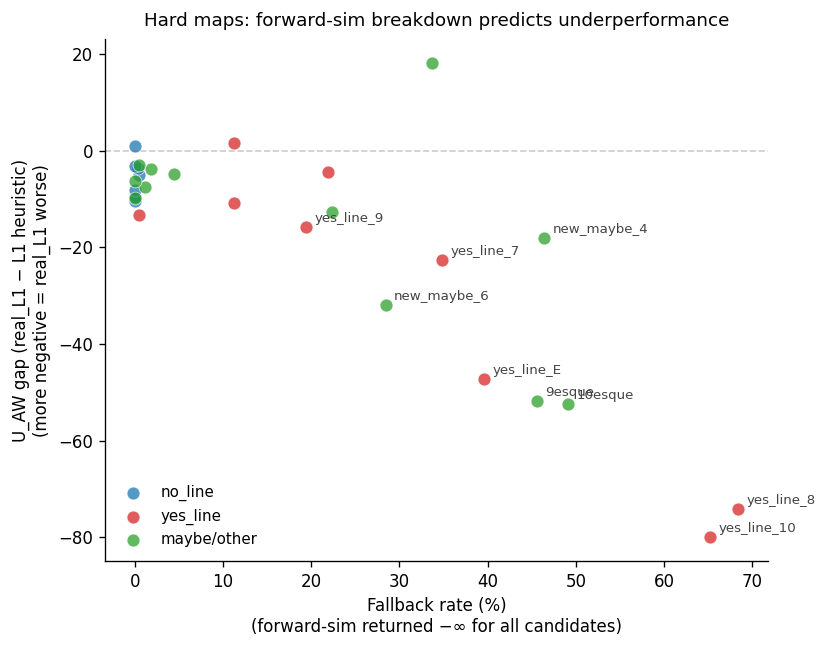

Saved figures/disagreement_per_map.png


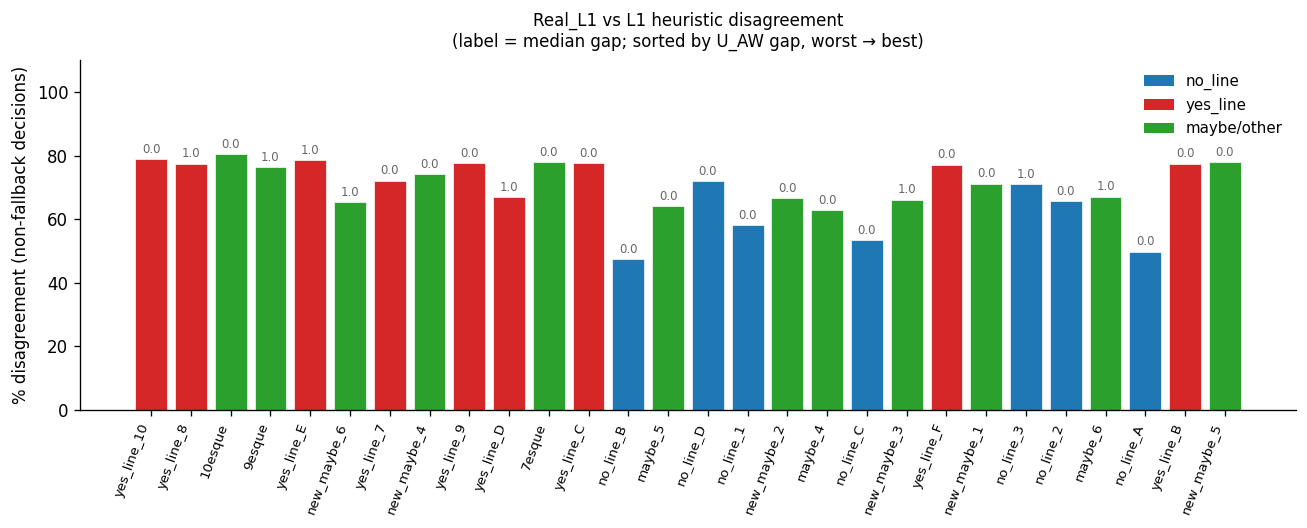

,map,pct_disagree,median_gap,n_nofb,uaw_gap,macro
19,yes_line_10,78.931751,0.0,337,-80.000000,yes_line
21,yes_line_8,77.510040,1.0,249,-74.125000,yes_line
0,10esque,80.387409,0.0,413,-52.500000,maybe/other
2,9esque,76.419214,1.0,229,-51.875000,maybe/other
26,yes_line_E,78.510638,1.0,470,-47.250000,yes_line
11,new_maybe_6,65.292842,1.0,461,-31.958333,maybe/other
20,yes_line_7,72.168285,0.0,309,-22.625000,yes_line
9,new_maybe_4,74.215247,0.0,446,-18.125000,maybe/other
22,yes_line_9,77.623762,0.0,505,-15.750000,yes_line
25,yes_line_D,66.844920,1.0,374,-13.250000,yes_line


In [24]:
# `result` is the per_map dataframe you computed earlier (with uaw_gap, pct_fallback, etc.)
fig_fallback_vs_gap(result, save_path='figures/fallback_vs_gap.png')

# `diff` is the output of compare_models()
fig_disagreement_when_evaluating(
    diff, result,
    save_path='figures/disagreement_per_map.png'
)


Saved figures/disagreement_per_map_t1.png


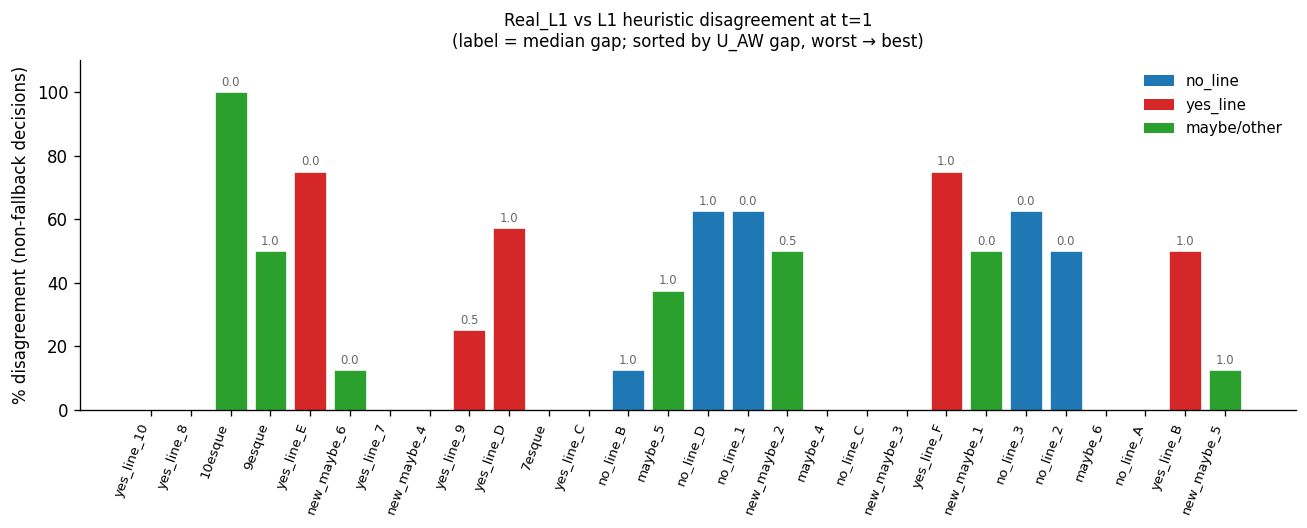

,map,pct_disagree,median_gap,n_nofb,uaw_gap,macro
19,yes_line_10,0.000000,NaN,1,-80.000000,yes_line
21,yes_line_8,0.000000,NaN,1,-74.125000,yes_line
0,10esque,100.000000,0.0,1,-52.500000,maybe/other
2,9esque,50.000000,1.0,2,-51.875000,maybe/other
26,yes_line_E,75.000000,0.0,8,-47.250000,yes_line
11,new_maybe_6,12.500000,0.0,8,-31.958333,maybe/other
20,yes_line_7,0.000000,NaN,1,-22.625000,yes_line
9,new_maybe_4,0.000000,NaN,8,-18.125000,maybe/other
22,yes_line_9,25.000000,0.5,8,-15.750000,yes_line
25,yes_line_D,57.142857,1.0,7,-13.250000,yes_line


In [25]:
fig_disagreement_when_evaluating(
    diff, result,
    restrict_to_t=1,
    save_path='figures/disagreement_per_map_t1.png'
)

In [46]:
"""
Trajectory analysis figures — extended set.

Figures:
1. fig_fallback_vs_gap          — scatter, fallback% vs U_AW gap (already had)
2. fig_disagreement_by_map      — full per-map bars (already had; cluttered)
3. fig_disagreement_binned      — simpler version: 3 bars by difficulty
4. fig_gap_distribution         — log-native: histogram of gap among disagreements
5. fig_sd_vs_log_metric         — does aggregate SD predict log-derived metrics?
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def _macro_type(name):
    name = str(name)
    if 'no_line' in name: return 'no_line'
    if 'yes_line' in name: return 'yes_line'
    return 'maybe/other'


MACRO_COLORS = {
    'no_line': 'tab:blue',
    'yes_line': 'tab:red',
    'maybe/other': 'tab:green',
}


# (existing fig_fallback_vs_gap and fig_disagreement_when_evaluating live above
# in your file — these are the additions)


# ---------------------------------------------------------------------------
# Figure 3: Simpler binned disagreement (3 bars by difficulty bucket)
# ---------------------------------------------------------------------------

def fig_disagreement_binned(diff_df, per_map_df,
                             gap_col='uaw_gap',
                             easy_thresh=-5, hard_thresh=-30,
                             save_path=None):
    """
    Bin maps into easy / medium / hard by U_AW gap, then show:
      - % disagreement (non-fallback) per bucket
      - Median gap of disagreements per bucket

    Tells the story 'noise rate is similar everywhere, but on hard maps the
    outcome is much worse' very compactly.

    diff_df: output of compare_models()
    per_map_df: with 'map' and gap_col
    easy_thresh / hard_thresh: U_AW gap thresholds for binning
                               (gap > easy_thresh = easy; gap < hard_thresh = hard)
    """
    # Bin maps
    bins = []
    for _, r in per_map_df.iterrows():
        g = r[gap_col]
        if g > easy_thresh:
            bin_name = 'easy\n(|gap| < 5)'
        elif g > hard_thresh:
            bin_name = 'medium\n(5 ≤ |gap| < 30)'
        else:
            bin_name = 'hard\n(|gap| ≥ 30)'
        bins.append({'map': r['map'], 'bucket': bin_name})
    bin_df = pd.DataFrame(bins)
    diff_with_bin = diff_df.merge(bin_df, on='map')

    # Compute per-bucket stats
    rows = []
    for bucket, sub in diff_with_bin.groupby('bucket'):
        nofb = sub[sub['tag_real_L1'] == 'OK']
        n_disagree = (~nofb['agreed']).sum()
        n_fb = (sub['tag_real_L1'] == 'FALLBACK').sum()
        disagrees = nofb[~nofb['agreed']]
        rows.append({
            'bucket': bucket,
            'n_maps': bin_df[bin_df['bucket'] == bucket]['map'].nunique(),
            'n_decisions': len(sub),
            'pct_fallback': 100 * n_fb / len(sub),
            'pct_disagree_nofb': 100 * n_disagree / max(len(nofb), 1),
            'median_gap_disagree': disagrees['gap_real_L1'].median()
                                    if len(disagrees) else np.nan,
        })
    summary = pd.DataFrame(rows)

    # Order: easy → medium → hard
    bucket_order = [b for b in ['easy\n(|gap| < .5)',
                                 'medium\n(.5 ≤ |gap| < 3)',
                                 'hard\n(|gap| ≥ 3)']
                    if b in summary['bucket'].values]
    summary = summary.set_index('bucket').reindex(bucket_order).reset_index()

    # Plot — two panels side by side: fallback rate, then disagreement rate
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))

    # Panel 1: fallback rate
    ax = axes[0]
    bars = ax.bar(range(len(summary)), summary['pct_fallback'],
                   color=['#4C9EE0', '#E89B5C', '#CC4444'][:len(summary)],
                   edgecolor='white')
    for i, v in enumerate(summary['pct_fallback']):
        ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=10)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(summary['bucket'], fontsize=9)
    ax.set_ylabel('Fallback rate (%)', fontsize=10)
    ax.set_title('Forward-sim breakdown\n(fewer evaluations succeed on hard maps)', fontsize=10)
    ax.set_ylim(0, max(summary['pct_fallback']) * 1.2 + 5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel 2: disagreement rate, with median gap as label
    ax = axes[1]
    bars = ax.bar(range(len(summary)), summary['pct_disagree_nofb'],
                   color=['#4C9EE0', '#E89B5C', '#CC4444'][:len(summary)],
                   edgecolor='white')
    for i, (v, mg) in enumerate(zip(summary['pct_disagree_nofb'],
                                      summary['median_gap_disagree'])):
        ax.text(i, v + 1.5,
                f'{v:.0f}%\n(med gap: {mg:.1f})',
                ha='center', fontsize=8)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(summary['bucket'], fontsize=9)
    ax.set_ylabel('% disagreement (non-fallback)', fontsize=10)
    ax.set_title('When forward-sim succeeds, real_L1 disagrees\n(median gap ≈ 0 → noise-driven)', fontsize=10)
    ax.set_ylim(0, max(summary['pct_disagree_nofb']) * 1.2 + 8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return summary


# ---------------------------------------------------------------------------
# Figure 4: Log-native — gap distribution among disagreements
# ---------------------------------------------------------------------------

def fig_gap_distribution(diff_df, per_map_df,
                          gap_col='uaw_gap',
                          easy_thresh=-5, hard_thresh=-30,
                          xmax=10,
                          save_path=None):
    """
    Histogram of `gap_real_L1` among non-fallback disagreements, split by
    map difficulty. Visualizes the "median ≈ 0" finding directly.

    A spike at gap=0 means many disagreements were essentially ties between
    candidate actions — the choice is noise-driven (optimizer's curse).

    Long tail toward higher gap = some disagreements reflect genuine preference.
    """
    bins = []
    for _, r in per_map_df.iterrows():
        g = r[gap_col]
        bin_name = 'easy' if g > easy_thresh else ('hard' if g < hard_thresh else 'medium')
        bins.append({'map': r['map'], 'bucket': bin_name})
    bin_df = pd.DataFrame(bins)
    merged = diff_df.merge(bin_df, on='map')

    nofb = merged[merged['tag_real_L1'] == 'OK']
    disagrees = nofb[~nofb['agreed']]

    # Clip gap to xmax for visualization
    disagrees = disagrees.copy()
    disagrees['gap_clipped'] = disagrees['gap_real_L1'].clip(upper=xmax)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    bin_edges = np.linspace(0, xmax, 21)  # 0.5-wide bins to xmax
    bucket_colors = {'easy': '#4C9EE0', 'medium': '#E89B5C', 'hard': '#CC4444'}

    for bucket in ['easy', 'medium', 'hard']:
        sub = disagrees[disagrees['bucket'] == bucket]
        if len(sub) == 0: continue
        ax.hist(sub['gap_clipped'].dropna(), bins=bin_edges,
                alpha=0.55, label=f"{bucket} (n={len(sub)})",
                color=bucket_colors[bucket],
                edgecolor='white', linewidth=0.4)

    # Reference line at gap=1 (the "close call" threshold)
    ax.axvline(1.0, color='#888', linestyle='--', linewidth=1, alpha=0.7,
               label='gap = 1.0 threshold')

    ax.set_xlabel('Gap (best − second-best evaluated value)\nlower = closer call',
                   fontsize=10)
    ax.set_ylabel('Number of disagreements', fontsize=10)
    ax.set_title('Distribution of decision gaps when real_L1 disagrees with L1 heuristic',
                  fontsize=11, pad=8)
    ax.legend(fontsize=9, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return disagrees


# ---------------------------------------------------------------------------
# Figure 5: aggregate SD vs log-derived metrics
# ---------------------------------------------------------------------------

def fig_sd_vs_log_metric(per_map_df, sims, sd_col='univ_aggregate_welfare_sd',
                          tag='real L1',
                          save_path=None):
    """
    Two scatters: aggregate SD (from non-verbose 5-run runs) vs log-derived
    metrics (fallback %, disagreement %).

    Tests whether aggregate SD is a proxy for the log-derived mechanism
    measures. Useful for the paper: 'we don't need to run trajectories on
    every map; the aggregate SD already tells us where forward-sim breaks down.'

    per_map_df: includes 'map', 'pct_fallback', 'pct_disagree' (or whatever
                you computed from logs)
    sims:        dict[tag] -> aggregated DataFrame with sd_col
    """
    # Merge SD into per_map_df
    sd_df = sims[tag][['map', sd_col]].rename(columns={sd_col: 'sd'})
    merged = per_map_df.merge(sd_df, on='map')
    merged['macro'] = merged['map'].apply(_macro_type)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    for ax, (xcol, xlabel, title) in zip(axes, [
        ('pct_fallback', 'Fallback rate (%)', f'Aggregate SD vs fallback rate'),
        ('pct_disagree', '% disagreement', f'Aggregate SD vs disagreement rate'),
    ]):
        if xcol not in merged.columns:
            ax.text(0.5, 0.5, f'No column "{xcol}" in per_map_df',
                    transform=ax.transAxes, ha='center')
            continue

        for macro, color in MACRO_COLORS.items():
            sub = merged[merged['macro'] == macro]
            if len(sub) == 0: continue
            ax.scatter(sub[xcol], sub['sd'],
                       c=color, s=50, alpha=0.7,
                       edgecolor='white', linewidth=0.4,
                       label=macro, zorder=2)

        # Label outliers
        top = merged.nlargest(3, 'sd')
        for _, r in top.iterrows():
            ax.annotate(r['map'], (r[xcol], r['sd']),
                        fontsize=7, color='#444',
                        xytext=(4, 3), textcoords='offset points')

        if len(merged.dropna(subset=[xcol, 'sd'])) > 2:
            r = np.corrcoef(merged[xcol].fillna(0), merged['sd'].fillna(0))[0, 1]
            title = f'{title}  (r = {r:.2f})'

        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(f'SD across runs ({tag})', fontsize=10)
        ax.set_title(title, fontsize=10, pad=6)
        ax.legend(fontsize=8, frameon=False, loc='upper left')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return merged

Saved figures/disagreement_binned.png


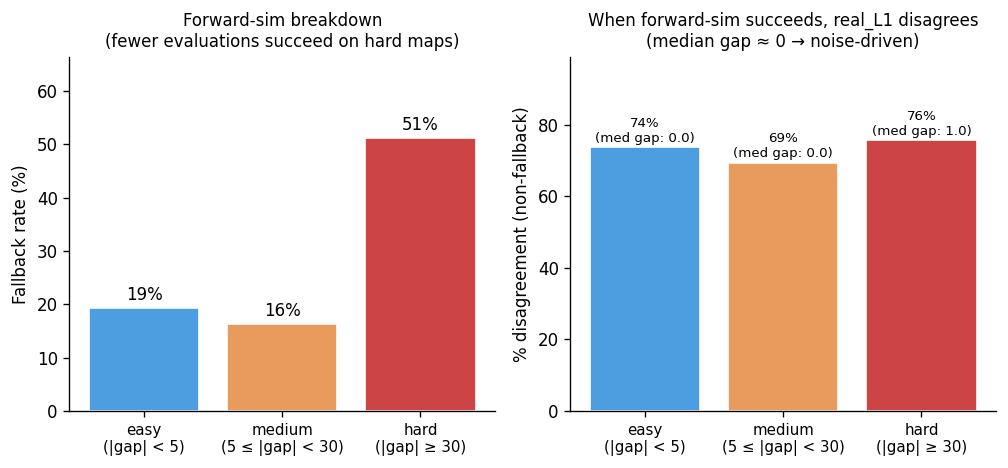

Saved figures/gap_distribution.png


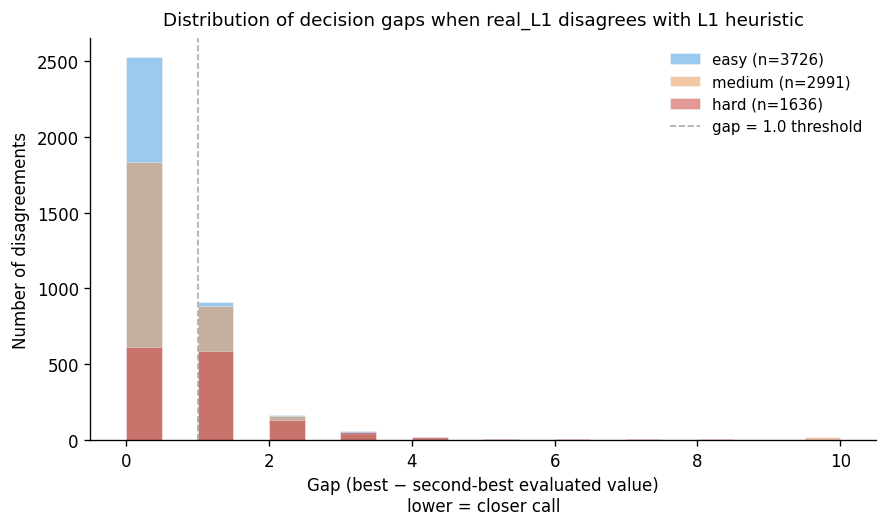

Saved figures/sd_vs_log.png


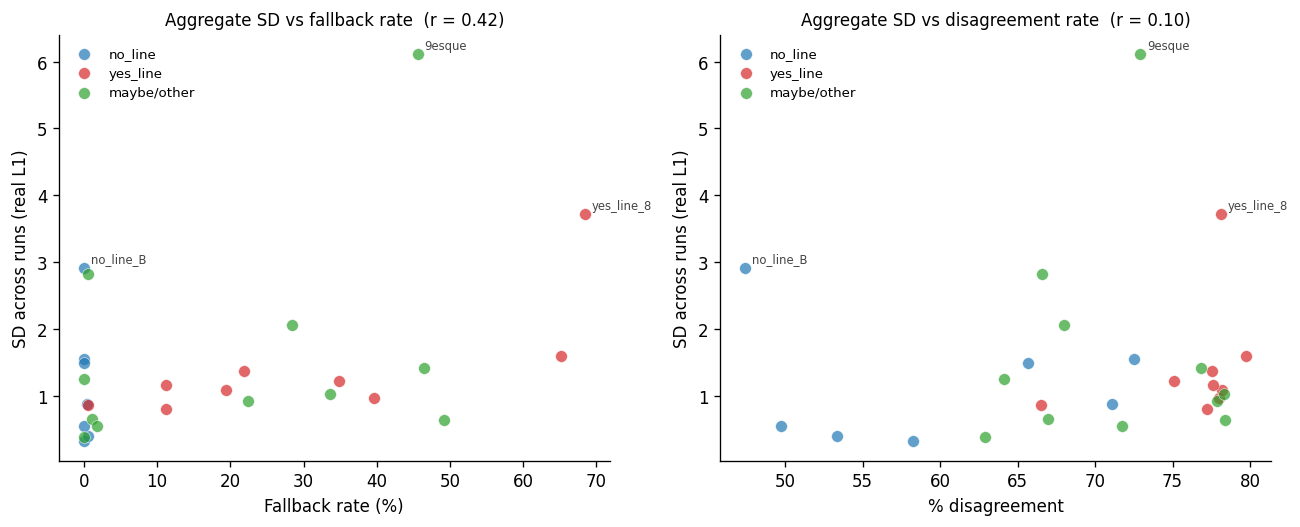

,map,real_stuck,heur_stuck,real_uaw,heur_uaw,uaw_gap,real_mean_t,heur_mean_t,mean_t_gap,max_agent_gap,pct_disagree,pct_fallback,pct_disagree_nofb,pct_close_of_disagree,sd,macro
0,yes_line_10,False,False,-161.125000,-81.125,-80.000000,161.125000,81.125,80.000000,133,79.732510,65.226337,78.931751,14.193548,1.588206,yes_line
1,yes_line_8,False,False,-143.500000,-69.375,-74.125000,143.500000,69.375,74.125000,160,78.148148,68.395062,77.510040,12.006319,3.718854,yes_line
2,10esque,False,False,-114.250000,-61.750,-52.500000,114.250000,61.750,52.500000,126,78.378378,49.140049,80.387409,29.467085,0.632642,maybe/other
3,9esque,False,False,-91.000000,-39.125,-51.875000,91.000000,39.125,51.875000,87,72.921615,45.605701,76.419214,9.120521,6.107163,maybe/other
4,yes_line_E,False,False,-124.375000,-77.125,-47.250000,124.375000,77.125,47.250000,109,78.020566,39.588689,78.510638,19.275124,0.967648,yes_line
5,new_maybe_6,True,False,-93.833333,-61.875,-31.958333,93.833333,61.875,31.958333,99,68.006182,28.438949,65.292842,21.590909,2.061623,maybe/other
6,yes_line_7,False,False,-65.375000,-42.750,-22.625000,65.375000,42.750,22.625000,97,75.105485,34.810127,72.168285,31.179775,1.223777,yes_line
7,new_maybe_4,False,False,-95.000000,-76.875,-18.125000,95.000000,76.875,18.125000,69,76.802885,46.394231,74.215247,33.176839,1.411200,maybe/other
8,yes_line_9,False,False,-62.750000,-47.000,-15.750000,62.750000,47.000,15.750000,92,78.219396,19.395866,77.623762,50.609756,1.088919,yes_line
9,yes_line_D,False,False,-48.625000,-35.375,-13.250000,48.625000,35.375,13.250000,61,66.490765,0.527704,66.844920,46.031746,0.864931,yes_line


In [27]:
# Simpler binned version of fig 2
fig_disagreement_binned(diff, result,
    save_path='figures/disagreement_binned.png')

# Log-native gap distribution
fig_gap_distribution(diff, result,
    save_path='figures/gap_distribution.png')

# SD vs log metrics
fig_sd_vs_log_metric(result, sims, tag='real L1',
    save_path='figures/sd_vs_log.png')

In [28]:
# Missing maps on real L@
import pandas as pd
import os

# Original real_L2 main run (the big one)
main_label = RUNS['real L2']  # whatever it is, e.g. 'real_L2_5runs_<timestamp>' or similar
main_dir = f"../data/simulations/{main_label}/raw"

# All possible (map, run) combos: 28 maps × 5 runs
all_maps = sims['real L2']['map'].tolist()  # or hardcode if needed
all_combos = set((m, r) for m in all_maps for r in [1, 2, 3, 4, 5])

# What we have
have = set()
for fn in os.listdir(main_dir):
    if not fn.endswith('.csv'): continue
    m = fn[:-4]  # strip .csv
    df = pd.read_csv(f"{main_dir}/{fn}")
    for r in df['run'].unique():
        have.add((m, int(r)))

# Add fill data
fill_dirs = [d for d in os.listdir('../data/simulations') 
             if d.startswith('real_L2_fill_run') and '2026-05-05' in d]
for d in fill_dirs:
    raw = f'../data/simulations/{d}/raw'
    if not os.path.exists(raw): continue
    for fn in os.listdir(raw):
        if not fn.endswith('.csv'): continue
        m = fn[:-4]
        df = pd.read_csv(f"{raw}/{fn}")
        for r in df['run'].unique():
            have.add((m, int(r)))

missing = sorted(all_combos - have)
print(f"Missing {len(missing)}/140 (map, run) combos:")
for m, r in missing:
    print(f"  {m} run={r}")

Missing 10/140 (map, run) combos:
  10esque run=1
  7esque run=4
  maybe_6 run=2
  new_maybe_5 run=1
  yes_line_10 run=1
  yes_line_10 run=5
  yes_line_8 run=1
  yes_line_8 run=2
  yes_line_8 run=4
  yes_line_8 run=5


In [31]:
«

SyntaxError: invalid character '«' (U+00AB) (3295285591.py, line 1)

In [32]:
«««««

SyntaxError: invalid character '«' (U+00AB) (3132803868.py, line 1)

In [49]:
import os
import pandas as pd

real_proc = '../data/simulations/real_L1_traj_2026-05-05_120942/processed'
heur_proc = '../data/simulations/L1_heuristic_traj_2026-05-05_104641/processed'

def load_uaw(proc_dir):
    rows = []
    for fn in os.listdir(proc_dir):
        if not fn.endswith('.csv'): continue
        df = pd.read_csv(f'{proc_dir}/{fn}')
        # 1 run per file in trajectory data
        if 'aggregate_welfare' in df.columns and not df.empty:
            r = df.iloc[0]
            rows.append({'map': fn[:-4], 'aw': r['aggregate_welfare']})
    return pd.DataFrame(rows)

real_aw = load_uaw(real_proc).rename(columns={'aw': 'aw_real'})
heur_aw = load_uaw(heur_proc).rename(columns={'aw': 'aw_heur'})
aw_table = real_aw.merge(heur_aw, on='map')
aw_table['uaw_gap_real'] = aw_table['aw_real'] - aw_table['aw_heur']

# Now merge with the per-map fallback rates from your earlier `result` table
result_with_real_uaw = result.drop(columns=['uaw_gap'], errors='ignore').merge(
    aw_table[['map', 'aw_real', 'aw_heur', 'uaw_gap_real']],
    on='map'
)
# Rename so figure code finds it under 'uaw_gap'
result_with_real_uaw = result_with_real_uaw.rename(columns={'uaw_gap_real': 'uaw_gap'})

Saved figures/fallback_vs_gap_TRUE_UAW.png


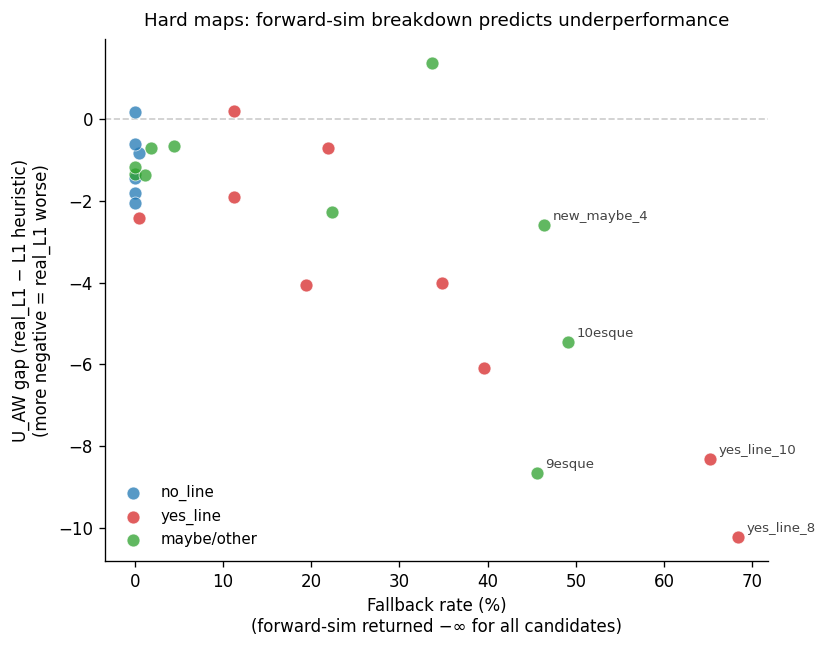

,map,real_stuck,heur_stuck,real_uaw,heur_uaw,real_mean_t,heur_mean_t,mean_t_gap,max_agent_gap,pct_disagree,pct_fallback,pct_disagree_nofb,pct_close_of_disagree,aw_real,aw_heur,uaw_gap,macro
0,yes_line_10,False,False,-161.125000,-81.125,161.125000,81.125,80.000000,133,79.732510,65.226337,78.931751,14.193548,-11.649351,-3.337662,-8.311688,yes_line
1,yes_line_8,False,False,-143.500000,-69.375,143.500000,69.375,74.125000,160,78.148148,68.395062,77.510040,12.006319,-14.086207,-3.862069,-10.224138,yes_line
2,10esque,False,False,-114.250000,-61.750,114.250000,61.750,52.500000,126,78.378378,49.140049,80.387409,29.467085,-6.779221,-1.324675,-5.454545,maybe/other
3,9esque,False,False,-91.000000,-39.125,91.000000,39.125,51.875000,87,72.921615,45.605701,76.419214,9.120521,-10.000000,-1.354167,-8.645833,maybe/other
4,yes_line_E,False,False,-124.375000,-77.125,124.375000,77.125,47.250000,109,78.020566,39.588689,78.510638,19.275124,-9.854839,-3.758065,-6.096774,yes_line
5,new_maybe_6,True,False,-93.833333,-61.875,93.833333,61.875,31.958333,99,68.006182,28.438949,65.292842,21.590909,NaN,-3.645833,NaN,maybe/other
6,yes_line_7,False,False,-65.375000,-42.750,65.375000,42.750,22.625000,97,75.105485,34.810127,72.168285,31.179775,-6.111111,-2.088889,-4.022222,yes_line
7,new_maybe_4,False,False,-95.000000,-76.875,95.000000,76.875,18.125000,69,76.802885,46.394231,74.215247,33.176839,-7.571429,-4.982143,-2.589286,maybe/other
8,yes_line_9,False,False,-62.750000,-47.000,62.750000,47.000,15.750000,92,78.219396,19.395866,77.623762,50.609756,-10.258065,-6.193548,-4.064516,yes_line
9,yes_line_D,False,False,-48.625000,-35.375,48.625000,35.375,13.250000,61,66.490765,0.527704,66.844920,46.031746,-3.386364,-0.977273,-2.409091,yes_line


In [50]:
fig_fallback_vs_gap(
    result_with_real_uaw,
    fallback_col='pct_fallback',
    gap_col='uaw_gap',
    save_path='figures/fallback_vs_gap_TRUE_UAW.png'
)


Saved figures/fallback_vs_gap.png


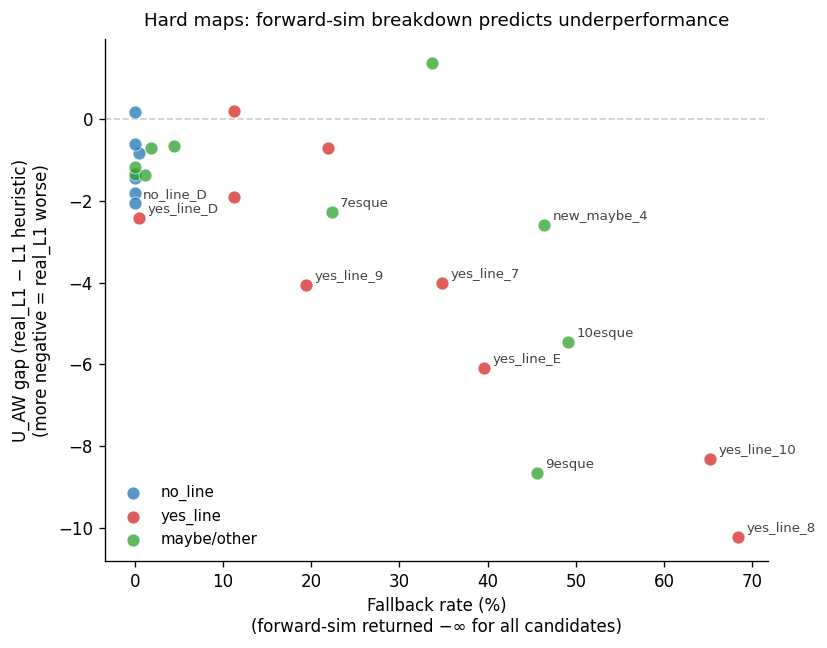

Saved figures/gap_distribution.png


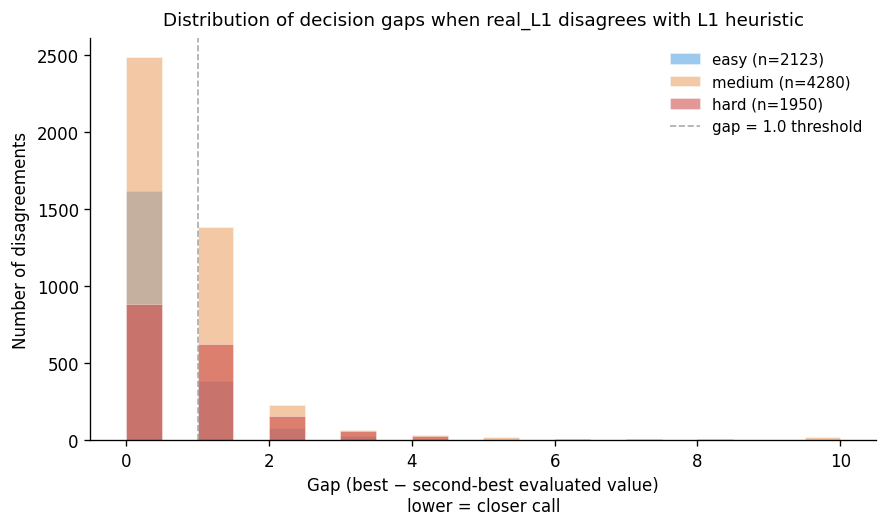

,map,run,t,idx,k,pos,chose_real_L1,tag_real_L1,best_real_L1,gap_real_L1,chose_L1_heur,tag_L1_heur,agreed,bucket,gap_clipped
4,10esque,1,1,5,1,"(9,5)",wait(agent1),OK,-27.0,0.0,up(agent1),HEUR,False,hard,0.0
49,10esque,1,7,5,1,"(9,2)",wait(agent1),OK,-18.0,1.0,down(agent1),HEUR,False,hard,1.0
65,10esque,1,9,5,1,"(9,3)",wait(agent1),OK,-20.0,3.0,left(agent1),HEUR,False,hard,3.0
73,10esque,1,10,5,1,"(9,3)",up(agent1),OK,-18.0,1.0,down(agent1),HEUR,False,hard,1.0
100,10esque,1,14,5,1,"(9,2)",down(agent1),OK,-14.0,NaN,right(agent1),HEUR,False,hard,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15894,yes_line_F,1,105,8,1,"(1,4)",wait(agent1),OK,0.0,0.0,down(agent1),HEUR,False,medium,0.0
15895,yes_line_F,1,106,1,5,"(3,11)",wait(agent5),OK,0.0,0.0,left(agent5),HEUR,False,medium,0.0
15896,yes_line_F,1,106,2,4,"(3,5)",left(agent4),OK,0.0,0.0,wait(agent4),HEUR,False,medium,0.0
15898,yes_line_F,1,106,5,3,"(2,6)",right(agent3),OK,0.0,0.0,wait(agent3),HEUR,False,medium,0.0


In [51]:

# Use result_with_real_uaw everywhere instead of result
df = result_with_real_uaw

# --- Figure 1: fallback vs U_AW gap (the headline) ---
# label_threshold_gap was -15 in mean-fill-time units; for U_AW divide by ~8
# i.e. threshold for labeling becomes -2 in U_AW terms (mark maps with gap < -2)
fig_fallback_vs_gap(
    df,
    fallback_col='pct_fallback',
    gap_col='uaw_gap',
    label_threshold_gap=-2,         # was -15
    label_threshold_fallback=40,
    save_path='figures/fallback_vs_gap.png'
)

# --- Figure 4: gap distribution histogram (this one doesn't depend on uaw_gap units) ---
# But the bucket thresholds do
fig_gap_distribution(
    diff, df,
    gap_col='uaw_gap',
    easy_thresh=-0.5,                # was -5
    hard_thresh=-3,                  # was -30
    save_path='figures/gap_distribution.png'
)



ValueError: max() arg is an empty sequence

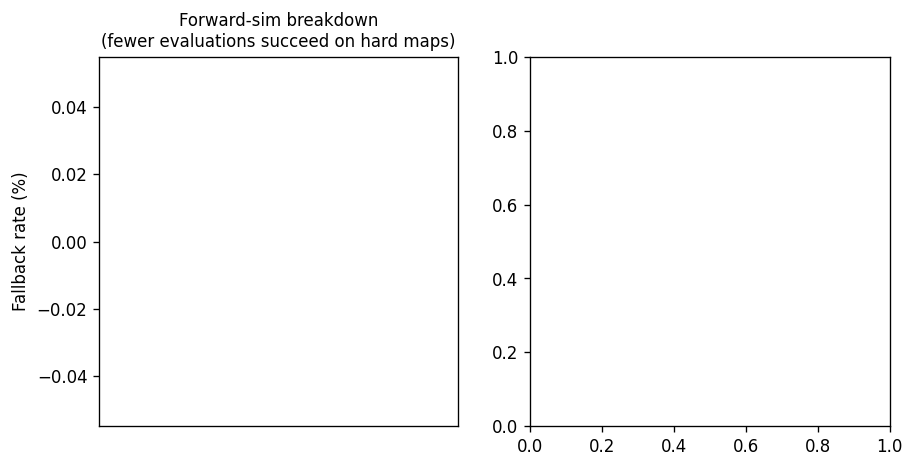

In [52]:
# --- Figure 3: binned disagreement (if you want it back) ---
fig_disagreement_binned(
    diff, df,
    gap_col='uaw_gap',
    easy_thresh=-0.5,                # was -5
    hard_thresh=-3,                  # was -30
    save_path='figures/disagreement_binned.png'
)

# --- Figure 2: full per-map bars (if needed) ---
fig_disagreement_when_evaluating(
    diff, df,
    sort_by='uaw_gap',
    save_path='figures/disagreement_per_map.png'
)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fig_gap_distribution_t1(diff_df, save_path=None):
    """
    Histogram of gap among non-fallback disagreements AT t=1 ONLY.
    
    At t=1, real_L1 and L1 heuristic see identical input states, so a 
    disagreement is a real per-state choice difference. The gap shows whether
    that choice was noise-driven (gap ≈ 0) or principled (gap > 1).
    
    Pooled across all maps (small n per map at t=1).
    """
    sub = diff_df[diff_df['t'] == 1]
    nofb = sub[sub['tag_real_L1'] == 'OK']
    disagrees = nofb[~nofb['agreed']].copy()
    
    print(f"Total t=1 decisions: {len(sub)}")
    print(f"  fallback: {(sub['tag_real_L1'] == 'FALLBACK').sum()}")
    print(f"  non-fallback: {len(nofb)}")
    print(f"  non-fallback disagreements: {len(disagrees)}")
    print(f"  median gap of disagreements: {disagrees['gap_real_L1'].median():.2f}")
    print(f"  mean gap of disagreements: {disagrees['gap_real_L1'].mean():.2f}")
    print(f"  % with gap < 1.0: {100 * (disagrees['gap_real_L1'] < 1.0).sum() / max(len(disagrees), 1):.1f}%")

    fig, ax = plt.subplots(figsize=(7, 4))
    
    # Use 0.5-wide bins clipped to [0, 6]
    xmax = 6
    disagrees['gap_clipped'] = disagrees['gap_real_L1'].clip(upper=xmax)
    bin_edges = np.arange(0, xmax + 0.5, 0.5)
    
    ax.hist(disagrees['gap_clipped'].dropna(), bins=bin_edges,
            color='#4477AA', edgecolor='white', linewidth=0.6)
    
    # Reference line at 1.0 — the "close call" threshold
    ax.axvline(1.0, color='#CC4444', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(1.05, ax.get_ylim()[1] * 0.92,
            'gap = 1.0\n(close-call threshold)',
            fontsize=8, color='#CC4444', va='top')
    
    ax.set_xlabel('Gap (best − second-best evaluated value)\nlower = closer call',
                  fontsize=10)
    ax.set_ylabel(f'Number of disagreements (n = {len(disagrees)})', fontsize=10)
    ax.set_title('At t=1 (identical states): real_L1 vs. L1 heuristic disagreements',
                  fontsize=11, pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return disagrees

Total t=1 decisions: 224
  fallback: 53
  non-fallback: 169
  non-fallback disagreements: 57
  median gap of disagreements: 0.00
  mean gap of disagreements: 0.46
  % with gap < 1.0: 54.4%
Saved figures/gap_distribution_t1.png


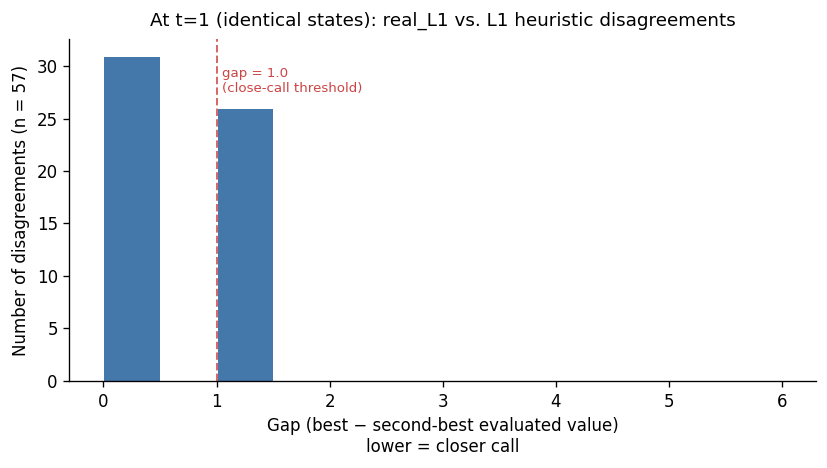

In [54]:
disagrees_t1 = fig_gap_distribution_t1(
    diff,
    save_path='figures/gap_distribution_t1.png'
)